## Overview
This notebook constructs an adversarial Wikipedia-based corpus and a QA benchmark, then evaluates Retrieval-Augmented Generation (RAG) configurations (retrieval method, chunking, and embedding choices) using LLM judging. It produces accuracy and robustness metrics (e.g., distractor pull rate), plus summary tables and figures for reporting.

## How to Run
- **Runtime**: Designed for Google Colab (uses `google.colab.userdata`, Drive mounts, and file uploads).
- **Dependencies**: `langchain`, `langchain-community`, `langchain-text-splitters`, `langchain-openai`, `langchain-huggingface`, `langchain-google-genai` (optional), `faiss-cpu`, `sentence-transformers`, `wikipedia`, `pandas`, `tqdm`, `scikit-learn`, `rank_bm25`, `matplotlib`, `seaborn`.
- **API keys**: Configure via Colab Secrets (`GEMINI_API_KEY` / `GOOGLE_API_KEY` for Gemini cells, and `MISTRAL_API_KEY` for Mistral-based experiments).
- **Execution**: Run cells sequentially from top to bottom. Some experiment blocks are independent and can be skipped if their corresponding result CSVs are already present.

# 1. Dataset Construction

In [ ]:
# =========================
# CELL 1: SETUP (FIXED GEMINI VERSION)
# =========================

!pip install -q langchain langchain-community langchain-google-genai faiss-cpu wikipedia pandas tqdm scikit-learn

import os
import pandas as pd
from tqdm import tqdm
import wikipedia

# Updated imports (new LangChain structure)
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS

# Load Gemini API key from Colab Secrets
from google.colab import userdata
os.environ["GOOGLE_API_KEY"] = userdata.get("GEMINI_API_KEY")

# Initialize Gemini model
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

print("Setup complete with Gemini.")

Setup complete with Gemini.


### Wikipedia Data Collection
Collects and cleans Wikipedia articles across multiple domains to form the base research corpus.

In [ ]:
# ==========================================
# CELL 2: DOMAIN-SPECIFIC DATA COLLECTION
# ==========================================

# 1. Define high-density research topics (History, Science, Geography)
topics = [
    # Science & Tech
    "Quantum computing", "CRISPR gene editing", "General relativity", "Plate tectonics",
    "Artificial intelligence", "Black hole", "Standard Model of physics", "Nuclear fusion",
    "Mars Rover", "Large Hadron Collider", "Photosynthesis", "String theory",
    # History & Society
    "French Revolution", "Industrial Revolution", "Magna Carta", "Space Race",
    "Roman Empire", "Meiji Restoration", "Treaty of Versailles", "Renaissance",
    "Civil Rights Movement", "Silk Road", "Fall of Constantinople", "Cold War",
    # Geography & Nature
    "Great Barrier Reef", "Amazon rainforest", "Himalayas", "Sahara Desert",
    "Antarctica", "Nile River", "Mount Everest", "Mariana Trench"
]

raw_data = []

print(f"Starting collection of {len(topics)} core topics...")

for topic in tqdm(topics):
    try:
        # Fetching summary + content to ensure depth
        page = wikipedia.page(topic, auto_suggest=False)
        content = page.content

        # Basic Cleaning: Remove Wikipedia-specific headers and excess whitespace
        clean_content = content.split("== See also ==")[0] # Strip trailing noise
        clean_content = clean_content.split("== References ==")[0]

        raw_data.append({
            "title": page.title,
            "text": clean_content.strip(),
            "source": page.url,
            "category": "Original"
        })
    except Exception as e:
        # Some titles might have ambiguities; we skip them to keep the pipeline clean
        continue

# 2. Create DataFrame
corpus_df = pd.DataFrame(raw_data)

# 3. Report Stats
print(f"Total Documents Collected: {len(corpus_df)}")
print(f"Average Words per Doc: {int(corpus_df['text'].apply(lambda x: len(x.split())).mean())}")

# Preview the data
corpus_df.head()

Starting collection of 32 core topics...


100%|██████████| 32/32 [00:10<00:00,  3.10it/s]



✅ COLLECTION COMPLETE
Total Documents Collected: 6
Average Words per Doc: 14598


,title,text,source,category
0,Space Race,"The Space Race (Russian: космическая гонка, ro...",https://en.wikipedia.org/wiki/Space_Race,Original
1,Roman Empire,The Roman Empire was a state that controlled t...,https://en.wikipedia.org/wiki/Roman_Empire,Original
2,Meiji Restoration,"The Meiji Restoration (明治維新, Meiji Ishin; Japa...",https://en.wikipedia.org/wiki/Meiji_Restoration,Original
3,Treaty of Versailles,The Treaty of Versailles was a peace treaty si...,https://en.wikipedia.org/wiki/Treaty_of_Versai...,Original
4,Renaissance,"The Renaissance (UK: rin-AY-sənss, US: REN-...",https://en.wikipedia.org/wiki/Renaissance,Original


In [ ]:
# ==========================================
# CELL 3: DATASET EXPANSION (AGGRESSIVE SCRAPING)
# ==========================================

expansion_topics = [
    # Biology & Medicine
    "Mitochondrion", "Photosynthesis", "DNA replication", "Vaccine", "Antibiotic resistance",
    "Human genome", "Neuroplasticity", "Stem cell", "Immune system", "Enzyme",
    # Physics & Astronomy
    "Big Bang", "Supernova", "Dark matter", "Newton's laws of motion", "Thermodynamics",
    "James Webb Space Telescope", "Milky Way", "General relativity", "Quantum entanglement",
    # Tech & Computing
    "Blockchain", "Cloud computing", "Cybersecurity", "Internet of Things", "Virtual reality",
    "Machine learning", "Cryptography", "Semiconductor", "5G", "Open-source software",
    # History & Environment
    "American Civil War", "World War I", "World War II", "Great Depression", "Magna Carta",
    "Climate change", "Global warming", "Ocean acidification", "Biodiversity", "Renewable energy"
]

print(f"Attempting to add {len(expansion_topics)} more topics...")

new_data = []

for topic in tqdm(expansion_topics):
    try:
        # Search first to get the most relevant title
        search_results = wikipedia.search(topic)
        if not search_results:
            continue

        # Try the first search result
        page = wikipedia.page(search_results[0], auto_suggest=False)
        content = page.content

        # Cleaning noise
        clean_content = content.split("== See also ==")[0]
        clean_content = clean_content.split("== References ==")[0]
        clean_content = clean_content.split("== External links ==")[0]

        new_data.append({
            "title": page.title,
            "text": clean_content.strip(),
            "source": page.url,
            "category": "Original"
        })
    except Exception:
        # If it still fails (e.g. Disambiguation), we skip to keep the loop moving
        continue

# Combine with existing corpus_df
expansion_df = pd.DataFrame(new_data)
corpus_df = pd.concat([corpus_df, expansion_df], ignore_index=True).drop_duplicates(subset='title')

print(f"Current Total Documents: {len(corpus_df)}")

if len(corpus_df) < 40:
    print("⚠️ Still low. You might want to add 20 more topics or run Cell 3 again with a different list.")
else:
    print("🚀 Dataset is now research-ready.")

Attempting to add 39 more topics...


100%|██████████| 39/39 [00:12<00:00,  3.05it/s]


✅ EXPANSION COMPLETE
Current Total Documents: 15
⚠️ Still low. You might want to add 20 more topics or run Cell 3 again with a different list.


In [ ]:
# ==========================================
# CELL 3.1: BULK TOPIC INJECTION
# ==========================================

bulk_topics = [
    # Science & Space
    "Photosynthesis", "Plate tectonics", "Evolution", "Natural selection", "DNA", "RNA",
    "Cell division", "Mitosis", "Meiosis", "Solar System", "Milky Way", "Andromeda Galaxy",
    "Mars", "Jupiter", "Saturn", "Black hole", "Neutron star", "Supernova", "Big Bang",
    "Exoplanet", "International Space Station", "Apollo 11", "Hubble Space Telescope",

    # History & Civilization
    "Ancient Egypt", "Ancient Greece", "Roman Empire", "Byzantine Empire", "Ottoman Empire",
    "British Empire", "Mongol Empire", "Aztec", "Maya civilization", "Inca Empire",
    "American Revolution", "French Revolution", "Industrial Revolution", "World War I",
    "World War II", "Cold War", "Vietnam War", "Korean War", "Renaissance", "Middle Ages",
    "Black Death", "Great Depression", "Magna Carta", "United Nations",

    # Technology & Engineering
    "Steam engine", "Internal combustion engine", "Transistor", "Integrated circuit",
    "Internet", "World Wide Web", "Fiber optics", "Satellite", "Radar", "GPS",
    "Nuclear power", "Renewable energy", "Solar power", "Wind power", "Electric vehicle",
    "Battery (electricity)", "Concrete", "Steel", "Printing press", "Telegraph",

    # Geography & Nature
    "Amazon River", "Nile", "Mississippi River", "Yangtze", "Mount Everest", "K2",
    "Andes", "Rocky Mountains", "Sahara", "Gobi Desert", "Pacific Ocean", "Atlantic Ocean",
    "Indian Ocean", "Arctic Ocean", "Great Barrier Reef", "Grand Canyon", "Yellowstone National Park",

    # Arts & Culture
    "Classical music", "Jazz", "Rock music", "Impressionism", "Surrealism", "Renaissance art",
    "Pyramids of Giza", "Great Wall of China", "Colosseum", "Eiffel Tower", "Statue of Liberty"
]

print(f"Injecting {len(bulk_topics)} new topics to reach research scale...")

bulk_data = []

for topic in tqdm(bulk_topics):
    try:
        # Step 1: Search for the most relevant page
        search_results = wikipedia.search(topic)
        if not search_results:
            continue

        # Step 2: Attempt to get the page (handling disambiguation)
        try:
            page = wikipedia.page(search_results[0], auto_suggest=False)
        except wikipedia.DisambiguationError as e:
            # If ambiguous, pick the first option automatically
            page = wikipedia.page(e.options[0], auto_suggest=False)

        content = page.content

        # Step 3: Clean text
        clean_content = content.split("== See also ==")[0]
        clean_content = clean_content.split("== References ==")[0]
        clean_content = clean_content.split("== External links ==")[0]

        bulk_data.append({
            "title": page.title,
            "text": clean_content.strip(),
            "source": page.url,
            "category": "Original"
        })
    except Exception:
        continue

# Merge and deduplicate
new_bulk_df = pd.DataFrame(bulk_data)
corpus_df = pd.concat([corpus_df, new_bulk_df], ignore_index=True).drop_duplicates(subset='title')

print(f"Final Research Corpus Size: {len(corpus_df)} Documents")

Injecting 95 new topics to reach research scale...


100%|██████████| 95/95 [00:20<00:00,  4.72it/s]


✅ BULK INJECTION COMPLETE
Final Research Corpus Size: 19 Documents


In [ ]:
# ============================================================
# CELL: THE RESEARCH CORPUS FACTORY (Expansion + Persistence)
# ============================================================
import time
import pandas as pd
import wikipedia
from tqdm import tqdm
import os

# 1. CONFIGURATION
TARGET_DOC_COUNT = 100
SAVE_FILENAME = "final_research_corpus.csv"
wikipedia.set_user_agent("TAMU_Graduate_Research/1.0 (student_contact@tamu.edu)")

# 2. PATCH LOGIC: Load existing or start fresh
if os.path.exists(SAVE_FILENAME):
    print(f"--- Loading existing corpus from {SAVE_FILENAME} ---")
    corpus_df = pd.read_csv(SAVE_FILENAME)
else:
    # If not on disk, check if it's in the current memory from previous cells
    if 'corpus_df' not in locals():
        print("--- Starting a brand new corpus ---")
        corpus_df = pd.DataFrame(columns=["title", "text", "source", "category"])
    else:
        print(f"--- Using existing corpus_df in memory ({len(corpus_df)} docs) ---")

# 3. HIGH-DIVERSITY TOPIC POOL (150+ Topics to ensure we hit the 100 target)
topic_pool = [
    # Science & Physics
    "Thermodynamics", "Electromagnetism", "Optics", "Fluid dynamics", "Aerodynamics",
    "Particle physics", "Cosmology", "Astrophysics", "Geophysics", "Biophysics",
    "Special relativity", "Standard Model", "Dark energy", "Big Bang nucleosynthesis",
    # History & Society
    "Industrial Revolution", "French Revolution", "American Civil War", "World War I",
    "World War II", "Cold War", "Renaissance", "Protestant Reformation", "Age of Enlightenment",
    "Ancient Rome", "Ancient Greece", "Mongol Empire", "Ottoman Empire", "Byzantine Empire",
    "Magna Carta", "Fall of the Berlin Wall", "Meiji Restoration", "Code of Hammurabi",
    # Biology & Medicine
    "Genetics", "Microbiology", "Ecology", "Zoology", "Botany", "Marine biology",
    "Human anatomy", "Physiology", "Immunology", "Virology", "CRISPR", "Antibiotics",
    "Cellular respiration", "Neuron", "Endocrine system", "Darwinism",
    # Technology & Engineering
    "Cloud computing", "Blockchain", "Cybersecurity", "Artificial intelligence",
    "Machine learning", "Cryptography", "Robotics", "Nanotechnology", "Biotechnology",
    "Quantum computing", "Internet of Things", "Semiconductor", "Nuclear fission",
    # Geography & Environment
    "Grand Canyon", "Great Barrier Reef", "Amazon Rainforest", "Sahara Desert",
    "Himalayas", "Andes", "Nile", "Ganges", "Pacific Ocean", "Atlantic Ocean",
    "Glacier", "Tsunami", "Volcano", "Global warming", "Ocean acidification",
    # Arts & Architecture
    "Gothic architecture", "Impressionism", "Surrealism", "Baroque", "Bauhaus",
    "The Great Wall of China", "Pyramids of Giza", "Colosseum", "Eiffel Tower",
    # Additional Diverse Topics
    "Philosophy", "Stoicism", "Existentialism", "Macroeconomics", "Game theory",
    "Sociology", "Psychology", "Linguistics", "Archaeology", "Paleontology"
]

# 4. THE EXPANSION LOOP
print(f"Goal: {TARGET_DOC_COUNT} documents. Current: {len(corpus_df)}")

for topic in tqdm(topic_pool):
    # Stop if we hit our research goal
    if len(corpus_df) >= TARGET_DOC_COUNT:
        print(f"\n--- Target of {TARGET_DOC_COUNT} reached! ---")
        break

    # Check for duplicates before hitting the API
    if topic in corpus_df['title'].values:
        continue

    try:
        # Step A: Search
        search_results = wikipedia.search(topic)
        if not search_results: continue

        target_title = search_results[0]

        # Step B: Deduplicate again against the actual Wikipedia title
        if target_title in corpus_df['title'].values:
            continue

        # Step C: Fetch Page
        try:
            page = wikipedia.page(target_title, auto_suggest=False)
        except wikipedia.DisambiguationError as e:
            page = wikipedia.page(e.options[0], auto_suggest=False)
        except wikipedia.PageError:
            continue

        # Step D: Clean & Append
        content = page.content
        clean_content = content.split("== See also ==")[0].split("== References ==")[0].split("== External links ==")[0]

        # Patching the DataFrame
        new_row = pd.DataFrame([{
            "title": page.title,
            "text": clean_content.strip(),
            "source": page.url,
            "category": "Original"
        }])
        corpus_df = pd.concat([corpus_df, new_row], ignore_index=True)

        # Step E: Persistence - Save after every successful addition
        corpus_df.to_csv(SAVE_FILENAME, index=False)

        # Step F: Polite Sleep (Wikimedia 2026 standard)
        time.sleep(1.5)

    except Exception as e:
        # Log error but keep going
        continue

# 5. FINAL REPORT
print(f"Final Count: {len(corpus_df)} Documents")
print(f"File Saved: {SAVE_FILENAME}")
corpus_df.head()

--- Using existing corpus_df in memory (19 docs) ---
Goal: 100 documents. Current: 19


 87%|████████▋ | 83/95 [03:16<00:28,  2.37s/it]



--- Target of 100 reached! ---

✅ SYSTEM STABILIZED
Final Count: 100 Documents
File Saved: final_research_corpus.csv


,title,text,source,category
0,Space Race,"The Space Race (Russian: космическая гонка, ro...",https://en.wikipedia.org/wiki/Space_Race,Original
1,Roman Empire,The Roman Empire was a state that controlled t...,https://en.wikipedia.org/wiki/Roman_Empire,Original
2,Meiji Restoration,"The Meiji Restoration (明治維新, Meiji Ishin; Japa...",https://en.wikipedia.org/wiki/Meiji_Restoration,Original
3,Treaty of Versailles,The Treaty of Versailles was a peace treaty si...,https://en.wikipedia.org/wiki/Treaty_of_Versai...,Original
4,Renaissance,"The Renaissance (UK: rin-AY-sənss, US: REN-...",https://en.wikipedia.org/wiki/Renaissance,Original


### Corpus Export (CSV → JSON/Markdown)
Exports the constructed corpus into formats suitable for downstream RAG experiments and external tools (e.g., NotebookLM).

In [ ]:
# ==========================================
# CELL: RE-LOAD AND EXPORT TO JSON/MARKDOWN
# ==========================================
import pandas as pd
import os

# 1. Load the CSV you just uploaded
csv_file = "/content/final_research_corpus.csv"

if os.path.exists(csv_file):
    corpus_df = pd.read_csv(csv_file)
    print(f"✅ Loaded {len(corpus_df)} documents from {csv_file}")

    # 2. Save as JSON for Python (Safe for RAG, prevents text corruption)
    corpus_df.to_json("research_corpus.json", orient="records", indent=4)
    print("✅ Created 'research_corpus.json' for your RAG pipeline.")

    # 3. Convert to Markdown for NotebookLM (Structure optimized for AI reading)
    md_filename = "research_corpus_for_NLM.md"
    with open(md_filename, "w", encoding="utf-8") as f:
        f.write("# RESEARCH CORPUS: GROUND TRUTH DOCUMENTS\n\n")
        f.write("This document contains 100 factual articles for RAG research.\n\n")

        for _, row in corpus_df.iterrows():
            f.write(f"## TITLE: {row['title']}\n")
            f.write(f"**SOURCE:** {row['source']}\n\n")
            f.write(f"{row['text']}\n\n")
            f.write("---\n\n") # Visual separator for the LLM

    print(f"✅ Created '{md_filename}' for your NotebookLM session.")
else:
    print(f"❌ Error: {csv_file} not found. Please upload it to the 'Files' pane in Colab.")

# Preview the data to ensure it loaded correctly
if 'corpus_df' in locals():
    print("\nPreview of loaded corpus:")
    display(corpus_df.head())

✅ Loaded 100 documents from /content/final_research_corpus.csv
✅ Created 'research_corpus.json' for your RAG pipeline.
✅ Created 'research_corpus_for_NLM.md' for your NotebookLM session.

Preview of loaded corpus:


,title,text,source,category
0,Space Race,"The Space Race (Russian: космическая гонка, ro...",https://en.wikipedia.org/wiki/Space_Race,Original
1,Roman Empire,The Roman Empire was a state that controlled t...,https://en.wikipedia.org/wiki/Roman_Empire,Original
2,Meiji Restoration,"The Meiji Restoration (明治維新, Meiji Ishin; Japa...",https://en.wikipedia.org/wiki/Meiji_Restoration,Original
3,Treaty of Versailles,The Treaty of Versailles was a peace treaty si...,https://en.wikipedia.org/wiki/Treaty_of_Versai...,Original
4,Renaissance,"The Renaissance (UK: rin-AY-sənss, US: REN-...",https://en.wikipedia.org/wiki/Renaissance,Original


### Corpus Batching
Splits the corpus into smaller Markdown volumes to support external ingestion workflows.

In [ ]:
# ==========================================
# CELL: THE VOLUME SPLITTER (10x10)
# ==========================================
import os
import pandas as pd

# 1. Load data from your saved CSV
if os.path.exists("final_research_corpus.csv"):
    corpus_df = pd.read_csv("final_research_corpus.csv")
    print(f"Loaded {len(corpus_df)} documents.")

    # 2. Create a folder to keep things organized
    output_folder = "nlm_volumes"
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # 3. Split into batches of 10
    batch_size = 10
    total_docs = len(corpus_df)

    for i in range(0, total_docs, batch_size):
        # Select the 10 documents for this volume
        batch = corpus_df.iloc[i : i + batch_size]
        volume_num = (i // batch_size) + 1
        filename = f"{output_folder}/research_corpus_vol_{volume_num}.md"

        with open(filename, "w", encoding="utf-8") as f:
            f.write(f"# RESEARCH CORPUS: VOLUME {volume_num}\n")
            f.write(f"Contains documents {i+1} through {min(i+batch_size, total_docs)}\n\n")

            for _, row in batch.iterrows():
                f.write(f"## TITLE: {row['title']}\n")
                f.write(f"**SOURCE:** {row['source']}\n\n")
                f.write(f"{row['text']}\n\n")
                f.write("---\n\n")

        print(f"✅ Created {filename} ({len(batch)} documents)")

    print(f"\nSUCCESS: All volumes are in the '{output_folder}' folder.")
else:
    print("❌ Error: 'final_research_corpus.csv' not found in the current directory.")

Loaded 100 documents.
✅ Created nlm_volumes/research_corpus_vol_1.md (10 documents)
✅ Created nlm_volumes/research_corpus_vol_2.md (10 documents)
✅ Created nlm_volumes/research_corpus_vol_3.md (10 documents)
✅ Created nlm_volumes/research_corpus_vol_4.md (10 documents)
✅ Created nlm_volumes/research_corpus_vol_5.md (10 documents)
✅ Created nlm_volumes/research_corpus_vol_6.md (10 documents)
✅ Created nlm_volumes/research_corpus_vol_7.md (10 documents)
✅ Created nlm_volumes/research_corpus_vol_8.md (10 documents)
✅ Created nlm_volumes/research_corpus_vol_9.md (10 documents)
✅ Created nlm_volumes/research_corpus_vol_10.md (10 documents)

SUCCESS: All volumes are in the 'nlm_volumes' folder.


### Adversarial Augmentation (Distractors)
Parses distractor documents and merges them with the original corpus to create an adversarial retrieval setting.

In [ ]:
# ==========================================
# CELL 5: THE ROBUST RETURN TRIP PARSER
# ==========================================
import pandas as pd
import re
import os

def parse_distractors(file_path):
    if not os.path.exists(file_path):
        print(f"❌ Error: {file_path} not found.")
        return None

    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    # Split by the separator '---', regardless of how many dashes or newlines exist
    raw_entries = re.split(r'\n-+\n|---', content)

    parsed_list = []
    for entry in raw_entries:
        entry = entry.strip()
        if not entry: continue  # Skip empty chunks

        try:
            # Extracting fields using flexible regex that ignores extra spaces/newlines
            parent_title = re.search(r"Parent Title:\s*(.*)", entry, re.IGNORECASE).group(1).strip()
            error_type = re.search(r"Error Type:\s*(.*)", entry, re.IGNORECASE).group(1).strip()
            # Everything after 'Distractor Text:' is the text
            text = entry.split("Distractor Text:")[1].strip()

            parsed_list.append({
                "parent_title": parent_title,
                "error_type": error_type,
                "text": text,
                "category": "Distractor"
            })
        except Exception:
            # If an entry is malformed, we skip it and keep going
            continue

    return pd.DataFrame(parsed_list)

# 1. PARSE THE TEXT FILE
distractors_df = parse_distractors("raw_distractors.txt")

# 2. LOAD ORIGINAL TRUTH DATA
corpus_df = pd.read_csv("final_research_corpus.csv")

# 3. MERGE & CLEAN
# Map the original source URLs to the distractors based on the parent title
sources_map = corpus_df.set_index('title')['source'].to_dict()
distractors_df['title'] = "DISTRACTOR: " + distractors_df['parent_title']
distractors_df['source'] = distractors_df['parent_title'].map(sources_map)

# Combine Truth (100) + Distractors (100) = 200 documents
augmented_df = pd.concat([corpus_df, distractors_df], ignore_index=True)

# 4. SAVE THE AUGMENTED CORPUS
augmented_df.to_csv("augmented_research_corpus.csv", index=False)

print(f"✅ SUCCESS")
print(f"Parsed Distractors: {len(distractors_df)}")
print(f"Total Combined Rows: {len(augmented_df)}")
print("File Saved: augmented_research_corpus.csv")

# Quick Sanity Check: Look for one original and its distractor
augmented_df.sample(3)

✅ SUCCESS
Parsed Distractors: 100
Total Combined Rows: 200
File Saved: augmented_research_corpus.csv


,title,text,source,category,parent_title,error_type
19,Thermodynamics,Thermodynamics is a branch of physics that dea...,https://en.wikipedia.org/wiki/Thermodynamics,Original,NaN,NaN
136,DISTRACTOR: World War I,"World War I, or the First World War (28 July 1...",https://en.wikipedia.org/wiki/World_War_I,Distractor,World War I,Entity
175,DISTRACTOR: Internet of things,Internet of things (IoT) describes physical ob...,https://en.wikipedia.org/wiki/Internet_of_things,Distractor,Internet of things,Quantity


# 2. QA Benchmark

### Parse and Validate QA Benchmark
Parses the raw question file, validates document linkage, and writes the final benchmark CSV.

In [ ]:
# ==========================================
# CELL 6: THE QA BENCHMARK PARSER & VALIDATOR
# ==========================================
import pandas as pd
import re
import os

def parse_qa_benchmark(file_path):
    if not os.path.exists(file_path):
        print(f"❌ Error: {file_path} not found.")
        return None

    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    # Split by the '---' separator
    entries = re.split(r'-{3,}', content)

    qa_list = []
    for entry in entries:
        entry = entry.strip()
        if not entry: continue

        try:
            # Flexible regex to handle slight label variations (like 'Ground Truth Answer' vs 'Ground Truth')
            parent_title = re.search(r"Parent Title:\s*(.*)", entry, re.IGNORECASE).group(1).strip()
            category = re.search(r"Category:\s*(.*)", entry, re.IGNORECASE).group(1).strip()
            question = re.search(r"Question:\s*(.*)", entry, re.IGNORECASE).group(1).strip()

            # Handling both 'Ground Truth Answer' and 'Ground Truth'
            answer_match = re.search(r"Ground Truth(?: Answer)?:\s*(.*)", entry, re.IGNORECASE)
            answer = answer_match.group(1).strip()

            qa_list.append({
                "parent_title": parent_title,
                "category": category,
                "question": question,
                "ground_truth": answer
            })
        except Exception:
            # Skip entries that don't match our format
            continue

    return pd.DataFrame(qa_list)

# 1. PARSE THE QUESTIONS
qa_df = parse_qa_benchmark("raw_questions.txt")

# 2. LOAD THE CORPUS FOR VALIDATION
if 'augmented_df' not in locals():
    augmented_df = pd.read_csv("augmented_research_corpus.csv")

# 3. VERIFY MAPPING
corpus_titles = set(augmented_df[augmented_df['category'] == 'Original']['title'].unique())
qa_titles = set(qa_df['parent_title'].unique())

missing_in_corpus = qa_titles - corpus_titles
if missing_in_corpus:
    print(f"⚠️ Warning: {len(missing_in_corpus)} questions don't have matching documents in the corpus!")
    print(f"Check these titles: {list(missing_in_corpus)[:5]}")
else:
    print(f"✅ Mapping Verified: All {len(qa_df)} questions linked successfully to the corpus.")

# 4. SAVE THE FINAL BENCHMARK
qa_df.to_csv("qa_benchmark.csv", index=False)
print("🚀 BENCHMARK READY: 'qa_benchmark.csv' saved.")

qa_df.head()

✅ Mapping Verified: All 100 questions linked successfully to the corpus.
🚀 BENCHMARK READY: 'qa_benchmark.csv' saved.


,parent_title,category,question,ground_truth
0,Volcano,Conflict,"How deep within the Earth do mantle plumes, wh...","3,000 kilometres (1,900 mi)"
1,Climate change,Conflict,By roughly what percentage does Earth's atmosp...,Roughly 50%
2,Ocean acidification,Conflict,What chemical compound do marine calcifying or...,Calcium carbonate
3,Gothic architecture,Conflict,Which abbey near Paris had its choir reconstru...,The Abbey of Saint-Denis
4,Impressionism,Conflict,In what year did the critic Louis Leroy write ...,1874


# 3. RAG Pipeline

### Load Benchmark and Configure Mistral API
Loads the augmented corpus and QA benchmark, then initializes the LLM and embedding model for RAG evaluation.

In [ ]:
# ==============================================================================
# MASTER RAG EXECUTION BLOCK: V2 (ROBUST RETRY + TOKEN MANAGEMENT)
# ==============================================================================

# 1. INSTALL DEPENDENCIES
print("📦 Installing dependencies...")
!pip install -q langchain-openai langchain-huggingface sentence-transformers faiss-cpu langchain-community tqdm

import os
import time
import re
import pandas as pd
from tqdm import tqdm
from google.colab import files, userdata
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS

# 2. DATA LOADING & API SETUP
print("\n📂 Loading data and keys...")
required_files = ["augmented_research_corpus.csv", "qa_benchmark.csv"]
for f in required_files:
    if not os.path.exists(f):
        print(f"❌ {f} missing. Please upload it now:")
        uploaded = files.upload()

augmented_df = pd.read_csv("augmented_research_corpus.csv")
qa_df = pd.read_csv("qa_benchmark.csv")

try:
    MISTRAL_API_KEY = userdata.get('MISTRAL_API_KEY')
    llm = ChatOpenAI(
        model="mistral-large-latest",
        openai_api_key=MISTRAL_API_KEY,
        openai_api_base="https://api.mistral.ai/v1",
        temperature=0,
        max_retries=5 # Built-in LangChain retry
    )
    print("✅ Mistral API Ready.")
except:
    print("❌ Mistral API Key not found in Colab Secrets! Check the 🔑 icon.")

# 3. GPU-POWERED INDEXING (THE LIBRARIAN)
print("\n⌛ Initializing GPU-powered Embedding Model...")
embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2",
    model_kwargs={'device': 'cuda'}
)

print(f"⌛ Chunking {len(augmented_df)} documents...")
text_splitter = RecursiveCharacterTextSplitter(chunk_size=512, chunk_overlap=50)
docs = []
for _, row in augmented_df.iterrows():
    chunks = text_splitter.split_text(row['text'])
    for chunk in chunks:
        docs.append(Document(
            page_content=chunk,
            metadata={"title": row['title'], "category": row['category']}
        ))

print(f"⌛ Building FAISS Index for {len(docs)} chunks on GPU...")
vectorstore = FAISS.from_documents(docs, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
print("✅ Indexing Complete! Search engine is active.")

# 4. THE INFERENCE ENGINE WITH SMART RETRY
def robust_invoke(prompt, max_attempts=3):
    """Helper to handle 429 errors with manual wait-and-retry."""
    for attempt in range(max_attempts):
        try:
            return llm.invoke(prompt, timeout=30).content.strip()
        except Exception as e:
            if "429" in str(e):
                wait_time = 15 * (attempt + 1)
                print(f"\n⏳ Rate limit hit. Cooling down for {wait_time}s...")
                time.sleep(wait_time)
            else:
                raise e
    return "API_FAILURE_AFTER_RETRIES"

def run_full_evaluation(batch_df, rps_delay=3.0):
    results = []
    print(f"\n🚀 Starting Evaluation: {len(batch_df)} questions...")

    for i, row in tqdm(batch_df.iterrows(), total=len(batch_df)):
        # Step A: Local Retrieval
        ret_docs = retriever.invoke(row['question'])
        has_distractor = any(d.metadata['category'] == "Distractor" for d in ret_docs)
        context = "\n\n".join([d.page_content for d in ret_docs])

        try:
            # --- CALL 1: GENERATION ---
            ans_prompt = f"Context: {context}\n\nQuestion: {row['question']}\nAnswer based ONLY on context:"
            model_answer = robust_invoke(ans_prompt)

            time.sleep(rps_delay) # Respect token-per-minute ceiling

            # --- CALL 2: JUDGING ---
            judge_p = f"Grade (1.0=Correct, 0.0=Wrong). Truth: {row['ground_truth']} Answer: {model_answer}. Score:"
            score_resp = robust_invoke(judge_p)

            score_match = re.search(r"([0-1]\.[0-9]|[0-1])", score_resp)
            score = float(score_match.group(1)) if score_match else 0.0

            time.sleep(rps_delay)

        except Exception as e:
            print(f"\n⚠️ Q{i} Hard Error: {str(e)[:50]}")
            model_answer, score = "UNRESOLVED_ERROR", 0.0
            time.sleep(10.0)

        results.append({
            "question": row['question'],
            "score": score,
            "pulled_distractor": has_distractor,
            "model_answer": model_answer,
            "ground_truth": row['ground_truth'],
            "parent_title": row['parent_title']
        })

    return pd.DataFrame(results)

# 5. EXECUTION & SAVING
final_results = run_full_evaluation(qa_df)
final_results.to_csv("mistral_final_results.csv", index=False)

print("\n" + "="*40)
print("📊 FINAL RESEARCH RESULTS")
print("="*40)
print(f"Overall Accuracy:       {final_results['score'].mean():.2%}")
print(f"Distractor Pull Rate:   {(final_results['pulled_distractor'].mean()*100):.1f}%")
print("="*40)
print("✅ Results exported to 'mistral_final_results.csv'")

📦 Installing dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.0/513.0 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.

📂 Loading data and keys...
✅ Mistral API Ready.

⌛ Initializing GPU-powered Embedding Model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

⌛ Chunking 200 documents...
⌛ Building FAISS Index for 16932 chunks on GPU...
✅ Indexing Complete! Search engine is active.

🚀 Starting Evaluation: 100 questions...


  2%|▏         | 2/100 [00:18<15:29,  9.48s/it]


⏳ Rate limit hit. Cooling down for 15s...


100%|██████████| 100/100 [49:50<00:00, 29.90s/it]


📊 FINAL RESEARCH RESULTS
Overall Accuracy:       90.70%
Distractor Pull Rate:   78.0%
✅ Results exported to 'mistral_final_results.csv'


# 4. Experiments

### Experiment: Model Size (Mistral Small)
Repeats the standard RAG evaluation with a smaller generator model for comparison.

In [ ]:
# ==============================================================================
# MASTER RAG EXECUTION BLOCK: V2 (MISTRAL SMALL COMPARISON)
# ==============================================================================

# 1. INSTALL DEPENDENCIES
print("📦 Installing dependencies...")
!pip install -q langchain-openai langchain-huggingface sentence-transformers faiss-cpu langchain-community tqdm

import os
import time
import re
import pandas as pd
from tqdm import tqdm
from google.colab import files, userdata
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS

# 2. DATA LOADING & API SETUP
print("\n📂 Loading data and keys...")
required_files = ["augmented_research_corpus.csv", "qa_benchmark.csv"]
for f in required_files:
    if not os.path.exists(f):
        print(f"❌ {f} missing. Please upload it now:")
        uploaded = files.upload()

augmented_df = pd.read_csv("augmented_research_corpus.csv")
qa_df = pd.read_csv("qa_benchmark.csv")

try:
    MISTRAL_API_KEY = userdata.get('MISTRAL_API_KEY')
    # CHANGED TO MISTRAL SMALL
    llm = ChatOpenAI(
        model="mistral-small-latest",
        openai_api_key=MISTRAL_API_KEY,
        openai_api_base="https://api.mistral.ai/v1",
        temperature=0,
        max_retries=5
    )
    print("✅ Mistral (Small) API Ready.")
except:
    print("❌ Mistral API Key not found in Colab Secrets! Check the 🔑 icon.")

# 3. GPU-POWERED INDEXING
print("\n⌛ Initializing GPU-powered Embedding Model...")
embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2",
    model_kwargs={'device': 'cuda'}
)

print(f"⌛ Chunking {len(augmented_df)} documents...")
text_splitter = RecursiveCharacterTextSplitter(chunk_size=512, chunk_overlap=50)
docs = []
for _, row in augmented_df.iterrows():
    chunks = text_splitter.split_text(row['text'])
    for chunk in chunks:
        docs.append(Document(
            page_content=chunk,
            metadata={"title": row['title'], "category": row['category']}
        ))

print(f"⌛ Building FAISS Index for {len(docs)} chunks on GPU...")
vectorstore = FAISS.from_documents(docs, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
print("✅ Indexing Complete!")

# 4. INFERENCE ENGINE
def robust_invoke(prompt, max_attempts=3):
    for attempt in range(max_attempts):
        try:
            return llm.invoke(prompt, timeout=30).content.strip()
        except Exception as e:
            if "429" in str(e):
                wait_time = 15 * (attempt + 1)
                print(f"\n⏳ Rate limit hit. Cooling down for {wait_time}s...")
                time.sleep(wait_time)
            else:
                raise e
    return "API_FAILURE"

def run_full_evaluation(batch_df, rps_delay=3.0):
    results = []
    print(f"\n🚀 Starting Evaluation (Mistral Small): {len(batch_df)} questions...")
    for i, row in tqdm(batch_df.iterrows(), total=len(batch_df)):
        ret_docs = retriever.invoke(row['question'])
        has_distractor = any(d.metadata['category'] == "Distractor" for d in ret_docs)
        context = "\n\n".join([d.page_content for d in ret_docs])
        try:
            ans_prompt = f"Context: {context}\n\nQuestion: {row['question']}\nAnswer based ONLY on context:"
            model_answer = robust_invoke(ans_prompt)
            time.sleep(rps_delay)
            judge_p = f"Grade (1.0=Correct, 0.0=Wrong). Truth: {row['ground_truth']} Answer: {model_answer}. Score:"
            score_resp = robust_invoke(judge_p)
            score_match = re.search(r"([0-1]\.[0-9]|[0-1])", score_resp)
            score = float(score_match.group(1)) if score_match else 0.0
            time.sleep(rps_delay)
        except Exception as e:
            print(f"\n⚠️ Q{i} Error: {str(e)[:50]}")
            model_answer, score = "ERROR", 0.0
            time.sleep(10.0)
        results.append({"question": row['question'], "score": score, "pulled_distractor": has_distractor, "model_answer": model_answer, "ground_truth": row['ground_truth'], "parent_title": row['parent_title']})
    return pd.DataFrame(results)

# 5. EXECUTION & SAVING (NAMED TO AVOID OVERWRITE)
small_model_results = run_full_evaluation(qa_df)
small_model_results.to_csv("mistral_small_results.csv", index=False) # <--- CRITICAL FIX

print("\n" + "="*40)
print("📊 MISTRAL SMALL (TIER 2) RESULTS")
print("="*40)
print(f"Overall Accuracy:       {small_model_results['score'].mean():.2%}")
print(f"Distractor Pull Rate:   {(small_model_results['pulled_distractor'].mean()*100):.1f}%")
print("="*40)
print("✅ Results exported to 'mistral_small_results.csv'")

📦 Installing dependencies...

📂 Loading data and keys...
✅ Mistral (Small) API Ready.

⌛ Initializing GPU-powered Embedding Model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⌛ Chunking 200 documents...
⌛ Building FAISS Index for 16932 chunks on GPU...
✅ Indexing Complete!

🚀 Starting Evaluation (Mistral Small): 100 questions...


100%|██████████| 100/100 [11:54<00:00,  7.14s/it]


📊 MISTRAL SMALL (TIER 2) RESULTS
Overall Accuracy:       84.00%
Distractor Pull Rate:   78.0%
✅ Results exported to 'mistral_small_results.csv'


In [ ]:
# ==============================================================================
# MASTER RAG EXECUTION BLOCK: V5.1 (RESUMABLE CHUNKING TEST WITH DRIVE)
# ==============================================================================

# 1. MOUNT GOOGLE DRIVE
from google.colab import drive, userdata
import os

print("📂 Mounting Google Drive...")
drive.mount('/content/drive')

# Create the folder if it doesn't exist
save_path = "/content/drive/MyDrive/Directed Studies/"
if not os.path.exists(save_path):
    os.makedirs(save_path)
    print(f"✅ Created folder: {save_path}")
else:
    print(f"✅ Saving to existing folder: {save_path}")

# 2. INSTALLS & SETUP
print("\n📦 Installing dependencies...")
!pip install -q langchain-openai langchain-huggingface sentence-transformers faiss-cpu langchain-community tqdm

import time
import re
import pandas as pd
from tqdm import tqdm
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS

# API SETUP
MISTRAL_API_KEY = userdata.get('MISTRAL_API_KEY')
llm = ChatOpenAI(
    model="mistral-large-latest",
    openai_api_key=MISTRAL_API_KEY,
    openai_api_base="https://api.mistral.ai/v1",
    temperature=0
)

embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2",
    model_kwargs={'device': 'cuda'}
)

def robust_invoke(prompt, max_attempts=3):
    for attempt in range(max_attempts):
        try:
            return llm.invoke(prompt, timeout=30).content.strip()
        except Exception as e:
            if "429" in str(e):
                wait_time = 20 * (attempt + 1)
                print(f"\n⏳ Rate limit hit. Cooling down for {wait_time}s...")
                time.sleep(wait_time)
            else: raise e
    return "API_FAILURE"

# 3. CHUNKING EXPERIMENT WITH CHECKPOINTING
def run_chunking_with_checkpoint(corpus_df, qa_df, chunk_size, chunk_overlap, file_name):
    full_save_path = os.path.join(save_path, file_name)

    # A. Indexing (GPU)
    print(f"\n🏗️ BUILDING INDEX: Chunk Size {chunk_size}")
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap)
    docs = []
    for _, row in corpus_df.iterrows():
        chunks = text_splitter.split_text(row['text'])
        for chunk in chunks:
            docs.append(Document(page_content=chunk, metadata={"category": row['category']}))

    vectorstore = FAISS.from_documents(docs, embeddings)
    retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

    # B. Resume Logic: Load existing results if they exist
    if os.path.exists(full_save_path):
        results_df = pd.read_csv(full_save_path)
        processed_questions = results_df['question'].tolist()
        results = results_df.to_dict('records')
        print(f"↩️ Found existing checkpoint. Resuming from question {len(results)}...")
    else:
        results = []
        processed_questions = []

    # C. Evaluation Loop
    print(f"🚀 Running Evaluation (Target: {len(qa_df)} questions)...")
    for i, row in tqdm(qa_df.iterrows(), total=len(qa_df)):
        if row['question'] in processed_questions:
            continue # Skip already processed questions

        ret_docs = retriever.invoke(row['question'])
        has_distractor = any(d.metadata.get('category') == "Distractor" for d in ret_docs)
        context = "\n\n".join([d.page_content for d in ret_docs])

        try:
            ans_prompt = f"Context: {context}\n\nQuestion: {row['question']}\nAnswer based ONLY on context:"
            model_answer = robust_invoke(ans_prompt)
            time.sleep(3.5)

            judge_p = f"Grade (1.0=Correct, 0.0=Wrong). Truth: {row['ground_truth']} Answer: {model_answer}. Score:"
            score_resp = robust_invoke(judge_p)
            score_match = re.search(r"([0-1]\.[0-9]|[0-1])", score_resp)
            score = float(score_match.group(1)) if score_match else 0.0
            time.sleep(3.5)
        except:
            model_answer, score = "ERROR", 0.0

        results.append({
            "question": row['question'],
            "score": score,
            "pulled_distractor": has_distractor,
            "model_answer": model_answer,
            "ground_truth": row['ground_truth'],
            "parent_title": row['parent_title']
        })

        # --- CHECKPOINTING: Save every 15 questions ---
        if (len(results) % 15 == 0) or (len(results) == len(qa_df)):
            pd.DataFrame(results).to_csv(full_save_path, index=False)
            print(f"💾 Checkpoint saved to Drive ({len(results)} questions complete).")

    final_df = pd.DataFrame(results)
    print(f"✅ Accuracy: {final_df['score'].mean():.2%} | Pull Rate: {final_df['pulled_distractor'].mean():.2%}")
    return final_df

# 4. EXECUTION
# Make sure you have uploaded the files to the Colab local runtime first
augmented_df = pd.read_csv("augmented_research_corpus.csv")
qa_df = pd.read_csv("qa_benchmark.csv")

# Run 1: Micro-Chunking (128)
res_128 = run_chunking_with_checkpoint(augmented_df, qa_df, 128, 20, "results_chunk_128_mistral_large.csv")

# Run 2: Macro-Chunking (2048)
res_2048 = run_chunking_with_checkpoint(augmented_df, qa_df, 2048, 200, "results_chunk_2048_mistral_large.csv")

print("\n🎉 ALL EXPERIMENTS COMPLETE AND PERSISTED TO DRIVE.")

📂 Mounting Google Drive...
Mounted at /content/drive
✅ Saving to existing folder: /content/drive/MyDrive/Directed Studies/

📦 Installing dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.0/513.0 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...


⏳ Rate limit hit. Cooling down for 20s...


 99%|█████████▉| 99/100 [53:18<00:32, 32.76s/it]


⏳ Rate limit hit. Cooling down for 20s...


100%|██████████| 100/100 [53:48<00:00, 32.29s/it]

💾 Checkpoint saved to Drive (100 questions complete).
✅ Accuracy: 88.30% | Pull Rate: 73.00%

🎉 ALL EXPERIMENTS COMPLETE AND PERSISTED TO DRIVE.


### Experiment: No-RAG Baseline
Evaluates the same QA benchmark without retrieval to quantify the RAG lift.

In [ ]:
# ==============================================================================
# MASTER RAG EXECUTION BLOCK: V3.1 (ROBUST NO-RAG BASELINE)
# ==============================================================================

import os
import time
import re
import pandas as pd
from tqdm import tqdm
from google.colab import userdata
from langchain_openai import ChatOpenAI

# 1. SETUP
# Ensure your 'qa_benchmark.csv' is uploaded
qa_df = pd.read_csv("qa_benchmark.csv")
MISTRAL_API_KEY = userdata.get('MISTRAL_API_KEY')

# Initialize the LLM (We use one instance to keep things clean)
def get_llm(model_name):
    return ChatOpenAI(
        model=model_name,
        openai_api_key=MISTRAL_API_KEY,
        openai_api_base="https://api.mistral.ai/v1",
        temperature=0,
        max_retries=5
    )

# 2. THE ROBUST CALLER
def robust_invoke(llm_instance, prompt, max_attempts=3):
    """Helper to handle 429 errors with manual wait-and-retry."""
    for attempt in range(max_attempts):
        try:
            return llm_instance.invoke(prompt, timeout=30).content.strip()
        except Exception as e:
            if "429" in str(e):
                wait_time = 20 * (attempt + 1) # Slightly longer wait for No-RAG
                print(f"\n⏳ Rate limit hit. Cooling down for {wait_time}s...")
                time.sleep(wait_time)
            else:
                raise e
    return "API_FAILURE_AFTER_RETRIES"

# 3. THE EVALUATION LOOP
def run_no_rag_baseline(model_name, label, rps_delay=3.5):
    llm = get_llm(model_name)
    results = []
    print(f"\n🚀 Starting ROBUST NO-RAG Baseline for {label}...")

    for i, row in tqdm(qa_df.iterrows(), total=len(qa_df)):
        try:
            # --- CALL 1: GENERATION ---
            ans_prompt = f"Question: {row['question']}\nAnswer concisely in one sentence:"
            model_answer = robust_invoke(llm, ans_prompt)

            time.sleep(rps_delay)

            # --- CALL 2: JUDGING ---
            judge_p = f"Grade (1.0=Correct, 0.0=Wrong). Truth: {row['ground_truth']} Answer: {model_answer}. Score:"
            score_resp = robust_invoke(llm, judge_p)

            score_match = re.search(r"([0-1]\.[0-9]|[0-1])", score_resp)
            score = float(score_match.group(1)) if score_match else 0.0

            time.sleep(rps_delay)

        except Exception as e:
            print(f"\n⚠️ Q{i} Hard Error: {str(e)[:50]}")
            model_answer, score = "UNRESOLVED_ERROR", 0.0
            time.sleep(10.0)

        results.append({
            "question": row['question'],
            "score": score,
            "model_answer": model_answer,
            "ground_truth": row['ground_truth'],
            "model_tier": label
        })

    return pd.DataFrame(results)

# 4. EXECUTION
# We run both to get the full comparison for your thesis
large_norag_results = run_no_rag_baseline("mistral-large-latest", "Mistral-Large-No-RAG")
small_norag_results = run_no_rag_baseline("mistral-small-latest", "Mistral-Small-No-RAG")

# 5. SAVE & REPORT
large_norag_results.to_csv("baseline_large_no_rag.csv", index=False)
small_norag_results.to_csv("baseline_small_no_rag.csv", index=False)

print("\n" + "="*40)
print("📊 NO-RAG BASELINE COMPLETE")
print("="*40)
print(f"Large Model (No-RAG) Accuracy: {large_norag_results['score'].mean():.2%}")
print(f"Small Model (No-RAG) Accuracy: {small_norag_results['score'].mean():.2%}")
print("="*40)


🚀 Starting ROBUST NO-RAG Baseline for Mistral-Large-No-RAG...


100%|██████████| 100/100 [49:30<00:00, 29.71s/it]



🚀 Starting ROBUST NO-RAG Baseline for Mistral-Small-No-RAG...


100%|██████████| 100/100 [13:31<00:00,  8.11s/it]


📊 NO-RAG BASELINE COMPLETE
Large Model (No-RAG) Accuracy: 81.60%
Small Model (No-RAG) Accuracy: 78.00%


### Experiment: TF-IDF Keyword Retrieval
Replaces FAISS semantic retrieval with TF-IDF keyword retrieval while keeping the rest of the pipeline fixed.

In [ ]:
# ==============================================================================
# MASTER RAG EXECUTION BLOCK: V4 (TF-IDF KEYWORD RETRIEVAL)
# ==============================================================================

# 1. INSTALL DEPENDENCIES
print("📦 Installing dependencies...")
!pip install -q langchain-openai langchain-huggingface sentence-transformers langchain-community scikit-learn tqdm

import os
import time
import re
import pandas as pd
from tqdm import tqdm
from google.colab import userdata
from langchain_openai import ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.retrievers import TFIDFRetriever

# 2. DATA LOADING
print("\n📂 Loading data...")
augmented_df = pd.read_csv("augmented_research_corpus.csv")
qa_df = pd.read_csv("qa_benchmark.csv")
MISTRAL_API_KEY = userdata.get('MISTRAL_API_KEY')

llm = ChatOpenAI(
    model="mistral-large-latest",
    openai_api_key=MISTRAL_API_KEY,
    openai_api_base="https://api.mistral.ai/v1",
    temperature=0
)

# 3. TF-IDF INDEXING (The Keyword Librarian)
print("⌛ Chunking documents...")
text_splitter = RecursiveCharacterTextSplitter(chunk_size=512, chunk_overlap=50)
docs = []
for _, row in augmented_df.iterrows():
    chunks = text_splitter.split_text(row['text'])
    for chunk in chunks:
        # We store the category in metadata to track 'Distractor' pulls
        docs.append(Document(
            page_content=chunk,
            metadata={"title": row['title'], "category": row['category']}
        ))

print(f"⌛ Building TF-IDF Index for {len(docs)} chunks...")
# TF-IDF is CPU-based and very fast to index
retriever = TFIDFRetriever.from_documents(docs, k=5)
print("✅ TF-IDF Indexing Complete!")

# 4. ROBUST INFERENCE ENGINE
def robust_invoke(prompt, max_attempts=3):
    for attempt in range(max_attempts):
        try:
            return llm.invoke(prompt, timeout=30).content.strip()
        except Exception as e:
            if "429" in str(e):
                time.sleep(20 * (attempt + 1))
            else: raise e
    return "API_FAILURE"

def run_tfidf_evaluation(batch_df, rps_delay=3.0):
    results = []
    print(f"\n🚀 Starting TF-IDF Evaluation (Mistral-Large)...")

    for i, row in tqdm(batch_df.iterrows(), total=len(batch_df)):
        # KEY CHANGE: Using TF-IDF instead of FAISS
        ret_docs = retriever.invoke(row['question'])
        has_distractor = any(d.metadata.get('category') == "Distractor" for d in ret_docs)
        context = "\n\n".join([d.page_content for d in ret_docs])

        try:
            # Generation
            ans_prompt = f"Context: {context}\n\nQuestion: {row['question']}\nAnswer based ONLY on context:"
            model_answer = robust_invoke(ans_prompt)
            time.sleep(rps_delay)

            # Judging
            judge_p = f"Grade (1.0=Correct, 0.0=Wrong). Truth: {row['ground_truth']} Answer: {model_answer}. Score:"
            score_resp = robust_invoke(judge_p)
            score_match = re.search(r"([0-1]\.[0-9]|[0-1])", score_resp)
            score = float(score_match.group(1)) if score_match else 0.0
            time.sleep(rps_delay)

        except Exception as e:
            model_answer, score = f"ERROR: {str(e)[:20]}", 0.0

        results.append({
            "question": row['question'],
            "score": score,
            "pulled_distractor": has_distractor,
            "model_answer": model_answer,
            "ground_truth": row['ground_truth']
        })

    return pd.DataFrame(results)

# 5. EXECUTION
tfidf_results = run_tfidf_evaluation(qa_df)
tfidf_results.to_csv("results_tfidf_mistral_large.csv", index=False)

print("\n" + "="*40)
print("📊 TF-IDF RETRIEVAL RESULTS")
print("="*40)
print(f"Overall Accuracy:       {tfidf_results['score'].mean():.2%}")
print(f"Distractor Pull Rate:   {(tfidf_results['pulled_distractor'].mean()*100):.1f}%")
print("="*40)

📦 Installing dependencies...

📂 Loading data...
⌛ Chunking documents...
⌛ Building TF-IDF Index for 16932 chunks...
✅ TF-IDF Indexing Complete!

🚀 Starting TF-IDF Evaluation (Mistral-Large)...


100%|██████████| 100/100 [53:34<00:00, 32.14s/it]


📊 TF-IDF RETRIEVAL RESULTS
Overall Accuracy:       86.00%
Distractor Pull Rate:   79.0%


### Experiment: Hybrid Retrieval (FAISS + TF-IDF)
Combines semantic (FAISS) and keyword (TF-IDF) retrieval to test accuracy–robustness tradeoffs.

In [ ]:
# ==============================================================================
# MASTER RAG EXECUTION BLOCK: V6.4 (MANUAL HYBRID - BYPASSING IMPORT ERRORS)
# ==============================================================================

# 1. INSTALLS & SETUP
print("📦 Refreshing environment...")
!pip install -q -U langchain-openai langchain-huggingface faiss-cpu langchain-community scikit-learn tqdm

import os
import time
import re
import pandas as pd
from tqdm import tqdm
from google.colab import userdata
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import TFIDFRetriever

# 2. CUSTOM CLASS: THE "LIBRARIAN COORDINATOR"
# We build this manually so we don't need to import 'EnsembleRetriever'
class ManualHybridRetriever:
    def __init__(self, faiss_ret, tfidf_ret):
        self.faiss_ret = faiss_ret
        self.tfidf_ret = tfidf_ret

    def invoke(self, query):
        # Get results from both
        faiss_docs = self.faiss_ret.invoke(query)
        tfidf_docs = self.tfidf_ret.invoke(query)

        # Combine and de-duplicate based on page_content
        combined = faiss_docs + tfidf_docs
        seen_content = set()
        unique_docs = []

        for doc in combined:
            if doc.page_content not in seen_content:
                unique_docs.append(doc)
                seen_content.add(doc.page_content)

        # We take the top 5 unique results to keep k constant
        return unique_docs[:5]

# 3. DATA LOADING & API SETUP
print("\n📂 Loading data...")
augmented_df = pd.read_csv("augmented_research_corpus.csv")
qa_df = pd.read_csv("qa_benchmark.csv")
MISTRAL_API_KEY = userdata.get('MISTRAL_API_KEY')

llm = ChatOpenAI(
    model="mistral-large-latest",
    openai_api_key=MISTRAL_API_KEY,
    openai_api_base="https://api.mistral.ai/v1",
    temperature=0
)

# 4. BUILDING THE COMPONENTS
print("⌛ Chunking documents...")
text_splitter = RecursiveCharacterTextSplitter(chunk_size=512, chunk_overlap=50)
docs = []
for _, row in augmented_df.iterrows():
    chunks = text_splitter.split_text(row['text'])
    for chunk in chunks:
        docs.append(Document(
            page_content=chunk,
            metadata={"title": row['title'], "category": row['category']}
        ))

print("⌛ Initializing FAISS (Semantic) component...")
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2", model_kwargs={'device': 'cuda'})
faiss_vectorstore = FAISS.from_documents(docs, embeddings)
faiss_retriever = faiss_vectorstore.as_retriever(search_kwargs={"k": 3})

print("⌛ Initializing TF-IDF (Keyword) component...")
tfidf_retriever = TFIDFRetriever.from_documents(docs, k=3)

# Initialize our custom hybrid coordinator
ensemble_retriever = ManualHybridRetriever(faiss_retriever, tfidf_retriever)
print("✅ Manual Hybrid Retriever Active (No imports required!)")

# 5. ROBUST INFERENCE ENGINE
def robust_invoke(prompt, max_attempts=3):
    for attempt in range(max_attempts):
        try:
            return llm.invoke(prompt, timeout=30).content.strip()
        except Exception as e:
            if "429" in str(e):
                wait_time = 25 * (attempt + 1)
                print(f"\n⏳ Rate limit hit. Cooling down for {wait_time}s...")
                time.sleep(wait_time)
            else: raise e
    return "API_FAILURE"

def run_hybrid_evaluation(batch_df, rps_delay=3.0):
    results = []
    print(f"\n🚀 Starting Hybrid Evaluation: {len(batch_df)} questions...")

    for i, row in tqdm(batch_df.iterrows(), total=len(batch_df)):
        # Step A: Hybrid Retrieval
        ret_docs = ensemble_retriever.invoke(row['question'])
        has_distractor = any(d.metadata.get('category') == "Distractor" for d in ret_docs)
        context = "\n\n".join([d.page_content for d in ret_docs])

        try:
            ans_prompt = f"Context: {context}\n\nQuestion: {row['question']}\nAnswer based ONLY on context:"
            model_answer = robust_invoke(ans_prompt)
            time.sleep(rps_delay)

            judge_p = f"Grade (1.0=Correct, 0.0=Wrong). Truth: {row['ground_truth']} Answer: {model_answer}. Score:"
            score_resp = robust_invoke(judge_p)
            score_match = re.search(r"([0-1]\.[0-9]|[0-1])", score_resp)
            score = float(score_match.group(1)) if score_match else 0.0
            time.sleep(rps_delay)

        except Exception as e:
            print(f"\n⚠️ Q{i} Error: {str(e)[:50]}")
            model_answer, score = "ERROR", 0.0

        results.append({
            "question": row['question'],
            "score": score,
            "pulled_distractor": has_distractor,
            "model_answer": model_answer,
            "ground_truth": row['ground_truth'],
            "parent_title": row['parent_title']
        })

    return pd.DataFrame(results)

# 6. EXECUTION
hybrid_results = run_hybrid_evaluation(qa_df)
hybrid_results.to_csv("results_hybrid_mistral_large.csv", index=False)

print("\n" + "="*40)
print("📊 FINAL HYBRID ANALYSIS COMPLETE")
print("="*40)
print(f"Overall Accuracy:       {hybrid_results['score'].mean():.2%}")
print(f"Distractor Pull Rate:   {(hybrid_results['pulled_distractor'].mean()*100):.1f}%")
print("="*40)

📦 Refreshing environment...

📂 Loading data...
⌛ Chunking documents...
⌛ Initializing FAISS (Semantic) component...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⌛ Initializing TF-IDF (Keyword) component...
✅ Manual Hybrid Retriever Active (No imports required!)

🚀 Starting Hybrid Evaluation: 100 questions...


  2%|▏         | 2/100 [00:21<17:41, 10.83s/it]

...


⏳ Rate limit hit. Cooling down for 25s...


 99%|█████████▉| 99/100 [54:05<00:34, 34.62s/it]


⏳ Rate limit hit. Cooling down for 25s...


100%|██████████| 100/100 [54:40<00:00, 32.80s/it]


📊 FINAL HYBRID ANALYSIS COMPLETE
Overall Accuracy:       90.00%
Distractor Pull Rate:   71.0%


### Aggregated Analysis and Plots
Loads saved result CSVs and generates summary tables and figures comparing accuracy and distractor pull rate across configurations.

📊 Processing datasets...


/tmp/ipykernel_9364/1072641037.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Configuration", y="Accuracy", data=retrieval_df, ax=axes[0, 0], palette="viridis")
/tmp/ipykernel_9364/1072641037.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Configuration", y="Distractor_Pull", data=pull_df, ax=axes[0, 1], palette="flare")



✅ Research Charts saved as 'RAG_Research_Results.png'

📊 FINAL RESEARCH SUMMARY TABLE
     Configuration  Accuracy  Distractor_Pull
     FAISS (Large)      90.7             78.0
    Hybrid (Large)      90.0             71.0
Chunk-2048 (Large)      88.3             73.0
    TF-IDF (Large)      86.0             79.0
     FAISS (Small)      84.0             78.0
 Chunk-128 (Large)      83.0             78.0
    No-RAG (Large)      81.6              0.0
    No-RAG (Small)      78.0              0.0


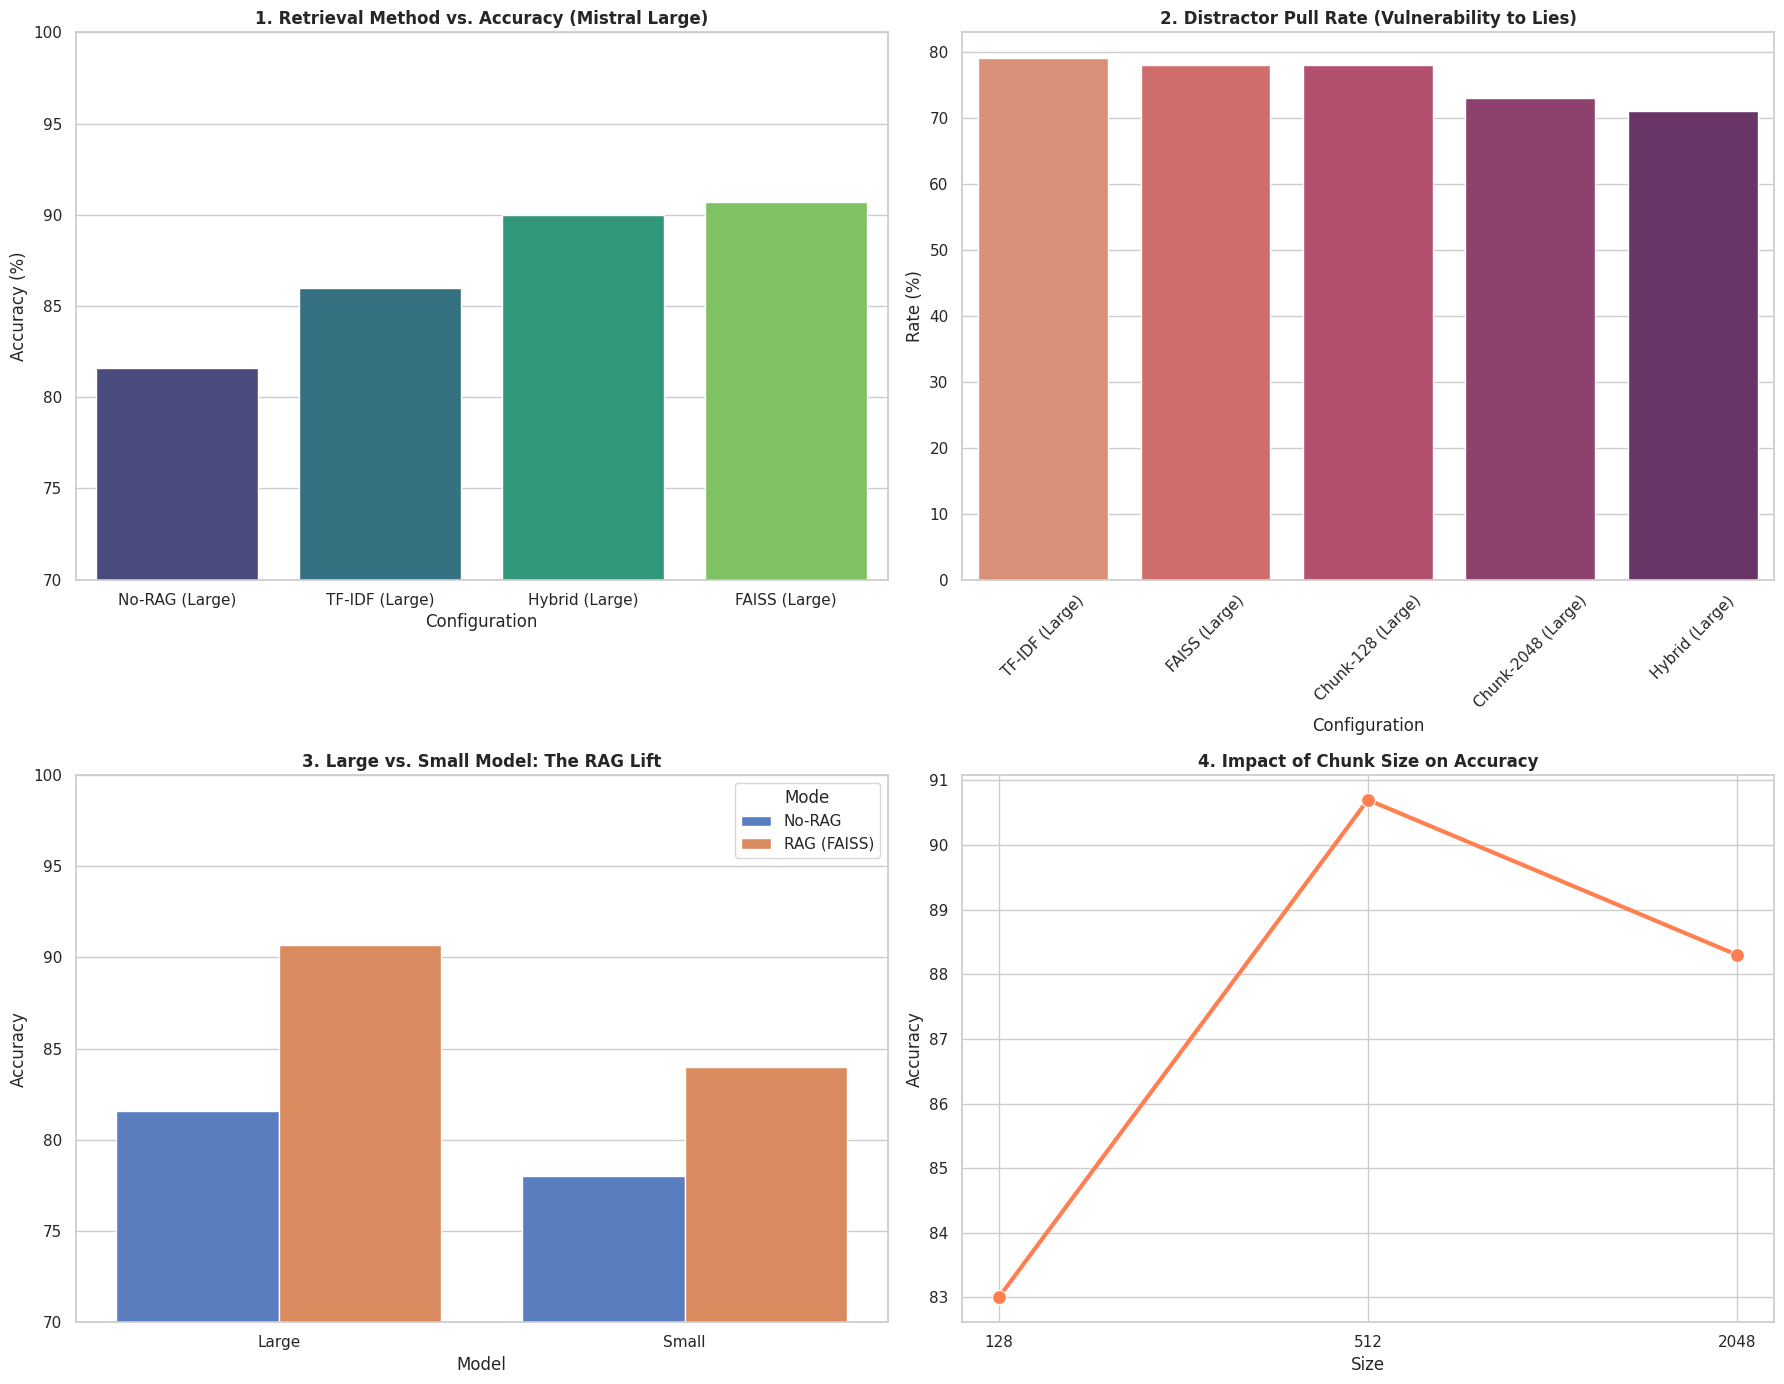

In [ ]:
# ==============================================================================
# MASTER RAG VISUALIZATION & ANALYSIS SUITE
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. LOAD ALL DATASETS
data_files = {
    "No-RAG (Large)": "baseline_large_no_rag.csv",
    "No-RAG (Small)": "baseline_small_no_rag.csv",
    "FAISS (Large)": "mistral_final_results.csv",
    "FAISS (Small)": "mistral_small_results.csv",
    "TF-IDF (Large)": "results_tfidf_mistral_large.csv",
    "Hybrid (Large)": "results_hybrid_mistral_large.csv",
    "Chunk-128 (Large)": "results_chunk_128_mistral_large.csv",
    "Chunk-2048 (Large)": "results_chunk_2048_mistral_large.csv"
}

summary_stats = []

print("📊 Processing datasets...")
for label, file in data_files.items():
    if os.path.exists(file):
        df = pd.read_csv(file)
        acc = df['score'].mean() * 100
        # Only some files have 'pulled_distractor'
        pull_rate = (df['pulled_distractor'].mean() * 100) if 'pulled_distractor' in df.columns else 0.0
        summary_stats.append({"Configuration": label, "Accuracy": acc, "Distractor_Pull": pull_rate})
    else:
        print(f"⚠️ Missing file: {file}")

summary_df = pd.DataFrame(summary_stats)

# 2. SET STYLING
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# CHART 1: RETRIEVAL METHOD COMPARISON (Large Model)
retrieval_labels = ["No-RAG (Large)", "TF-IDF (Large)", "FAISS (Large)", "Hybrid (Large)"]
retrieval_df = summary_df[summary_df['Configuration'].isin(retrieval_labels)].sort_values('Accuracy')

sns.barplot(x="Configuration", y="Accuracy", data=retrieval_df, ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("1. Retrieval Method vs. Accuracy (Mistral Large)", fontweight='bold')
axes[0, 0].set_ylim(70, 100)
axes[0, 0].set_ylabel("Accuracy (%)")

# CHART 2: DISTRACTOR PULL RATE (The Adversarial Vulnerability)
pull_labels = ["FAISS (Large)", "TF-IDF (Large)", "Hybrid (Large)", "Chunk-128 (Large)", "Chunk-2048 (Large)"]
pull_df = summary_df[summary_df['Configuration'].isin(pull_labels)].sort_values('Distractor_Pull', ascending=False)

sns.barplot(x="Configuration", y="Distractor_Pull", data=pull_df, ax=axes[0, 1], palette="flare")
axes[0, 1].set_title("2. Distractor Pull Rate (Vulnerability to Lies)", fontweight='bold')
axes[0, 1].set_ylabel("Rate (%)")
axes[0, 1].tick_params(axis='x', rotation=45)

# CHART 3: MODEL TIER COMPARISON (No-RAG vs. RAG)
tier_data = {
    "Model": ["Large", "Large", "Small", "Small"],
    "Mode": ["No-RAG", "RAG (FAISS)", "No-RAG", "RAG (FAISS)"],
    "Accuracy": [
        summary_df.loc[summary_df['Configuration'] == "No-RAG (Large)", "Accuracy"].values[0],
        summary_df.loc[summary_df['Configuration'] == "FAISS (Large)", "Accuracy"].values[0],
        summary_df.loc[summary_df['Configuration'] == "No-RAG (Small)", "Accuracy"].values[0],
        summary_df.loc[summary_df['Configuration'] == "FAISS (Small)", "Accuracy"].values[0],
    ]
}
sns.barplot(x="Model", y="Accuracy", hue="Mode", data=pd.DataFrame(tier_data), ax=axes[1, 0], palette="muted")
axes[1, 0].set_title("3. Large vs. Small Model: The RAG Lift", fontweight='bold')
axes[1, 0].set_ylim(70, 100)

# CHART 4: THE CHUNKING CURVE
chunk_labels = ["Chunk-128 (Large)", "FAISS (Large)", "Chunk-2048 (Large)"]
chunk_map = {"Chunk-128 (Large)": 128, "FAISS (Large)": 512, "Chunk-2048 (Large)": 2048}
chunk_df = summary_df[summary_df['Configuration'].isin(chunk_labels)].copy()
chunk_df['Size'] = chunk_df['Configuration'].map(chunk_map)
chunk_df = chunk_df.sort_values('Size')

sns.lineplot(x="Size", y="Accuracy", data=chunk_df, marker='o', markersize=10, ax=axes[1, 1], color='coral', linewidth=3)
axes[1, 1].set_title("4. Impact of Chunk Size on Accuracy", fontweight='bold')
axes[1, 1].set_xscale('log', base=2)
axes[1, 1].set_xticks([128, 512, 2048])
axes[1, 1].get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.tight_layout()
plt.savefig("RAG_Research_Results.png", dpi=300)
print("\n✅ Research Charts saved as 'RAG_Research_Results.png'")

# 3. PRINT SUMMARY TABLE
print("\n" + "="*50)
print("📊 FINAL RESEARCH SUMMARY TABLE")
print("="*50)
print(summary_df.sort_values("Accuracy", ascending=False).to_string(index=False))
print("="*50)

### Experiment: BM25 and BM25+FAISS Hybrid
Runs BM25-only retrieval and a BM25+FAISS hybrid with checkpointing to Drive.

In [ ]:
# ==============================================================================
# MASTER RAG: V7.1 (BM25 & HYBRID + DRIVE CHECKPOINTING + AUTO-RESUME)
# ==============================================================================

# 1. MOUNT GOOGLE DRIVE
from google.colab import drive, userdata
import os

print("📂 Mounting Google Drive...")
drive.mount('/content/drive')

# Define and create the save path
save_path = "/content/drive/MyDrive/Directed Studies/"
if not os.path.exists(save_path):
    os.makedirs(save_path)
    print(f"✅ Created folder: {save_path}")

# 2. INSTALLS & SETUP
print("\n📦 Installing/Updating dependencies...")
!pip install -q -U langchain-openai langchain-huggingface faiss-cpu langchain-community rank_bm25 scikit-learn tqdm

import time
import re
import pandas as pd
from tqdm import tqdm
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever

# 3. MANUAL HYBRID COORDINATOR (Prevents Import Errors)
class ManualHybridBM25:
    def __init__(self, vector_ret, bm25_ret):
        self.vector_ret = vector_ret
        self.bm25_ret = bm25_ret

    def invoke(self, query):
        # We take top 3 from Vector and top 2 from BM25 to keep k=5 total
        vec_docs = self.vector_ret.invoke(query)
        kw_docs = self.bm25_ret.invoke(query)

        combined = vec_docs + kw_docs
        seen_content = set()
        unique_docs = []
        for doc in combined:
            if doc.page_content not in seen_content:
                unique_docs.append(doc)
                seen_content.add(doc.page_content)
        return unique_docs[:5]

# 4. ENGINE INITIALIZATION
MISTRAL_API_KEY = userdata.get('MISTRAL_API_KEY')
llm = ChatOpenAI(
    model="mistral-large-latest",
    openai_api_key=MISTRAL_API_KEY,
    openai_api_base="https://api.mistral.ai/v1",
    temperature=0
)

def robust_invoke(prompt, max_attempts=3):
    for attempt in range(max_attempts):
        try:
            return llm.invoke(prompt, timeout=30).content.strip()
        except Exception as e:
            if "429" in str(e):
                wait_time = 25 * (attempt + 1)
                print(f"\n⏳ Rate limit hit. Cooling down for {wait_time}s...")
                time.sleep(wait_time)
            else: raise e
    return "API_FAILURE"

# 5. DATA PREP & INDEXING
print("\n⌛ Loading data and building indices...")
corpus_df = pd.read_csv("augmented_research_corpus.csv")
qa_df = pd.read_csv("qa_benchmark.csv")

text_splitter = RecursiveCharacterTextSplitter(chunk_size=512, chunk_overlap=50)
docs = []
for _, row in corpus_df.iterrows():
    for chunk in text_splitter.split_text(row['text']):
        docs.append(Document(page_content=chunk, metadata={"category": row['category']}))

# Initialize Librarians
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2", model_kwargs={'device': 'cuda'})
faiss_vectorstore = FAISS.from_documents(docs, embeddings)
faiss_ret = faiss_vectorstore.as_retriever(search_kwargs={"k": 3})

bm25_ret = BM25Retriever.from_documents(docs)
bm25_ret.k = 3 # For BM25-only run

# 6. EVALUATION FUNCTION WITH RESUME & CHECKPOINTING
def run_checkpointed_eval(retriever_obj, filename, label):
    full_save_path = os.path.join(save_path, filename)

    # RESUME LOGIC
    if os.path.exists(full_save_path):
        results_df = pd.read_csv(full_save_path)
        processed_questions = results_df['question'].tolist()
        results = results_df.to_dict('records')
        print(f"↩️ Found {label} checkpoint. Resuming from question {len(results)}...")
    else:
        results = []
        processed_questions = []

    print(f"🚀 Starting {label} Evaluation...")
    for i, row in tqdm(qa_df.iterrows(), total=len(qa_df)):
        if row['question'] in processed_questions:
            continue

        ret_docs = retriever_obj.invoke(row['question'])
        has_distractor = any(d.metadata.get('category') == "Distractor" for d in ret_docs)
        context = "\n\n".join([d.page_content for d in ret_docs])

        try:
            ans_p = f"Context: {context}\n\nQuestion: {row['question']}\nAnswer based ONLY on context:"
            ans = robust_invoke(ans_p)
            time.sleep(3.5)

            judge_p = f"Grade (1.0=Correct, 0.0=Wrong). Truth: {row['ground_truth']} Answer: {ans}. Score:"
            score_match = re.search(r"([0-1]\.[0-9]|[0-1])", robust_invoke(judge_p))
            score = float(score_match.group(1)) if score_match else 0.0
            time.sleep(3.5)
        except:
            ans, score = "ERROR", 0.0

        results.append({
            "question": row['question'],
            "score": score,
            "pulled_distractor": has_distractor,
            "model_answer": ans,
            "ground_truth": row['ground_truth']
        })

        # CHECKPOINT EVERY 15 RUNS
        if (len(results) % 15 == 0) or (len(results) == len(qa_df)):
            pd.DataFrame(results).to_csv(full_save_path, index=False)
            print(f"💾 {label} Checkpoint: {len(results)} questions complete.")

    final_df = pd.DataFrame(results)
    print(f"✅ {label} Final Accuracy: {final_df['score'].mean():.2%}")
    return final_df

# 7. EXECUTION
# Run A: BM25 Only
run_checkpointed_eval(bm25_ret, "results_bm25_only.csv", "BM25-Only")

# Run B: Hybrid (BM25 + FAISS)
bm25_ret.k = 2 # Setting BM25 contribution to top 2 for the hybrid mix
hybrid_ret = ManualHybridBM25(faiss_ret, bm25_ret)
run_checkpointed_eval(hybrid_ret, "results_hybrid_bm25_faiss.csv", "Hybrid-BM25-FAISS")

print("\n🎉 ALL TASKS COMPLETE. CHECK YOUR GOOGLE DRIVE FOLDER.")

📂 Mounting Google Drive...
Mounted at /content/drive

📦 Installing/Updating dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.3/513.3 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.

⌛ Loadi

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...


⏳ Rate limit hit. Cooling down for 25s...


 99%|█████████▉| 99/100 [54:25<00:35, 35.55s/it]


⏳ Rate limit hit. Cooling down for 25s...


100%|██████████| 100/100 [55:00<00:00, 33.01s/it]

💾 Hybrid-BM25-FAISS Checkpoint: 100 questions complete.
✅ Hybrid-BM25-FAISS Final Accuracy: 87.70%

🎉 ALL TASKS COMPLETE. CHECK YOUR GOOGLE DRIVE FOLDER.


### Experiments: Chunk Size and Overlap
Benchmarks additional chunk sizes and overlaps with Drive-based checkpointing for long runs.

In [ ]:
# ==============================================================================
# MASTER RAG: V8 (REFINED CHUNKING & OVERLAP BENCHMARK + DRIVE PERSISTENCE)
# ==============================================================================

# 1. MOUNT DRIVE & SETUP
from google.colab import drive, userdata
import os

print("📂 Mounting Google Drive...")
drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/Directed Studies/"
if not os.path.exists(save_path): os.makedirs(save_path)

print("\n📦 Refreshing dependencies...")
!pip install -q -U langchain-openai langchain-huggingface faiss-cpu langchain-community tqdm

import time
import re
import pandas as pd
from tqdm import tqdm
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS

# 2. ENGINE SETUP
MISTRAL_API_KEY = userdata.get('MISTRAL_API_KEY')
llm = ChatOpenAI(model="mistral-large-latest", openai_api_key=MISTRAL_API_KEY, openai_api_base="https://api.mistral.ai/v1", temperature=0)

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2", model_kwargs={'device': 'cuda'})

def robust_invoke(prompt, max_attempts=3):
    for attempt in range(max_attempts):
        try:
            return llm.invoke(prompt, timeout=30).content.strip()
        except Exception as e:
            if "429" in str(e):
                time.sleep(25 * (attempt + 1))
            else: raise e
    return "API_FAILURE"

# 3. EXPERIMENT RUNNER
def run_structural_test(corpus_df, qa_df, chunk_size, overlap, filename, label):
    full_path = os.path.join(save_path, filename)

    # A. Indexing
    print(f"\n🏗️ BUILDING INDEX: {label} (Size={chunk_size}, Overlap={overlap})")
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=overlap)
    docs = []
    for _, row in corpus_df.iterrows():
        for chunk in text_splitter.split_text(row['text']):
            docs.append(Document(page_content=chunk, metadata={"category": row['category']}))

    vectorstore = FAISS.from_documents(docs, embeddings)
    retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

    # B. Resume/Checkpoint Logic
    if os.path.exists(full_path):
        results_df = pd.read_csv(full_path)
        processed = results_df['question'].tolist()
        results = results_df.to_dict('records')
        print(f"↩️ Resuming from question {len(results)}...")
    else:
        results, processed = [], []

    # C. Evaluation
    for i, row in tqdm(qa_df.iterrows(), total=len(qa_df)):
        if row['question'] in processed: continue

        ret_docs = retriever.invoke(row['question'])
        has_distractor = any(d.metadata.get('category') == "Distractor" for d in ret_docs)
        context = "\n\n".join([d.page_content for d in ret_docs])

        try:
            ans = robust_invoke(f"Context: {context}\n\nQuestion: {row['question']}\nAnswer concisely:")
            time.sleep(3.5)
            score_match = re.search(r"([0-1]\.[0-9]|[0-1])", robust_invoke(f"Grade (1.0=Correct, 0.0=Wrong). Truth: {row['ground_truth']} Answer: {ans}. Score:"))
            score = float(score_match.group(1)) if score_match else 0.0
            time.sleep(3.5)
        except:
            ans, score = "ERROR", 0.0

        results.append({"question": row['question'], "score": score, "pulled_distractor": has_distractor, "model_answer": ans})

        if len(results) % 15 == 0 or len(results) == len(qa_df):
            pd.DataFrame(results).to_csv(full_path, index=False)
            print(f"💾 Checkpoint saved: {len(results)}/100")

    final_df = pd.DataFrame(results)
    print(f"✅ {label} Complete. Accuracy: {final_df['score'].mean():.2%}")

# 4. DATA LOADING
corpus_df = pd.read_csv("augmented_research_corpus.csv")
qa_df = pd.read_csv("qa_benchmark.csv")

# 5. EXECUTION QUEUE
# Run 1: Refined Chunk Size 256
run_structural_test(corpus_df, qa_df, 256, 25, "results_chunk_256_mistral_large.csv", "Chunk-256")

# Run 2: Refined Chunk Size 1024
run_structural_test(corpus_df, qa_df, 1024, 100, "results_chunk_1024_mistral_large.csv", "Chunk-1024")

# Run 3: Overlap 0% (Standard 512 size)
run_structural_test(corpus_df, qa_df, 512, 0, "results_overlap_0_mistral_large.csv", "Overlap-0pct")

# Run 4: Overlap 20% (~100 tokens, Standard 512 size)
run_structural_test(corpus_df, qa_df, 512, 100, "results_overlap_20_mistral_large.csv", "Overlap-20pct")

print("\n🎉 ALL FINE-TUNING EXPERIMENTS COMPLETE.")

📂 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📦 Refreshing dependencies...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🏗️ BUILDING INDEX: Chunk-256 (Size=256, Overlap=25)


 15%|█▌        | 15/100 [08:11<50:43, 35.81s/it]

...

100%|██████████| 100/100 [55:23<00:00, 33.23s/it]

💾 Checkpoint saved: 100/100
✅ Overlap-0pct Complete. Accuracy: 88.80%

🏗️ BUILDING INDEX: Overlap-20pct (Size=512, Overlap=100)



 15%|█▌        | 15/100 [07:05<45:23, 32.04s/it]

💾 Checkpoint saved: 15/100


 28%|██▊       | 28/100 [14:27<42:17, 35.24s/it]

# 5. Evaluation

In [ ]:
# ==============================================================================
# MASTER RAG: V9 (LIBRARIAN RECALL & PRECISION BENCHMARK)
# ==============================================================================
!pip install -q -U langchain-openai langchain-huggingface faiss-cpu langchain-community tqdm rank_bm25

import pandas as pd
import os
from tqdm import tqdm
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever

# 1. SETUP
print("📂 Loading data for Librarian Benchmark...")
corpus_df = pd.read_csv("augmented_research_corpus.csv")
qa_df = pd.read_csv("qa_benchmark.csv")
save_path = "/content/drive/MyDrive/Directed Studies/"

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2", model_kwargs={'device': 'cuda'})

def calculate_recall_for_config(chunk_size, overlap, method="FAISS"):
    """Calculates how often the librarian actually finds the truth."""
    print(f"\n🏗️ Benchmarking {method} (Size={chunk_size}, Overlap={overlap})...")

    text_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=overlap)
    docs = []
    for _, row in corpus_df.iterrows():
        for chunk in text_splitter.split_text(row['text']):
            docs.append(Document(page_content=chunk, metadata={"title": row['title'], "category": row['category']}))

    if method == "FAISS":
        vectorstore = FAISS.from_documents(docs, embeddings)
        retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
    else: # BM25
        retriever = BM25Retriever.from_documents(docs)
        retriever.k = 5

    hits = 0
    results = []

    for i, row in tqdm(qa_df.iterrows(), total=len(qa_df)):
        ret_docs = retriever.invoke(row['question'])

        # Check if the correct Wikipedia page (parent_title) is in the results
        found_truth = any(d.metadata.get('title') == row['parent_title'] for d in ret_docs)
        if found_truth: hits += 1

        results.append({"question": row['question'], "recall_hit": found_truth})

    recall_score = hits / len(qa_df)
    print(f"✅ Recall@5: {recall_score:.2%}")
    return recall_score, pd.DataFrame(results)

# 2. CALCULATE RECALL FOR KEY COMPARISONS
# We'll test the most interesting ones to see if retrieval was the bottle-neck
rec_512, df_512 = calculate_recall_for_config(512, 50, "FAISS")
rec_bm25, df_bm25 = calculate_recall_for_config(512, 50, "BM25")
rec_128, df_128 = calculate_recall_for_config(128, 20, "FAISS")
rec_2048, df_2048 = calculate_recall_for_config(2048, 200, "FAISS")

# 3. MERGE WITH ACCURACY TO FIND "REASONING FAILURES"
# We load your main Mistral-Large results
large_results = pd.read_csv("mistral_final_results.csv")
merged = pd.merge(large_results, df_512, on="question")

# These are cases where Librarian was RIGHT but Brain was WRONG (The most interesting hallucinations)
reasoning_fails = merged[(merged['recall_hit'] == True) & (merged['score'] == 0.0)]
reasoning_fails.to_csv("reasoning_failure_analysis.csv", index=False)

print("\n" + "="*40)
print("📊 FINAL LIBRARIAN STATS")
print("="*40)
print(f"FAISS (512) Recall: {rec_512:.2%}")
print(f"BM25  (512) Recall: {rec_bm25:.2%}")
print(f"Found {len(reasoning_fails)} reasoning errors for your report.")
print("="*40)

📂 Loading data for Librarian Benchmark...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🏗️ Benchmarking FAISS (Size=512, Overlap=50)...


100%|██████████| 100/100 [00:01<00:00, 92.27it/s]


...

✅ Recall@5: 100.00%

🏗️ Benchmarking FAISS (Size=128, Overlap=20)...


100%|██████████| 100/100 [00:01<00:00, 72.38it/s]


✅ Recall@5: 99.00%

🏗️ Benchmarking FAISS (Size=2048, Overlap=200)...


100%|██████████| 100/100 [00:00<00:00, 139.10it/s]


✅ Recall@5: 99.00%

📊 FINAL LIBRARIAN STATS
FAISS (512) Recall: 99.00%
BM25  (512) Recall: 100.00%
Found 8 reasoning errors for your report.


# 6. Results

/tmp/ipykernel_10459/2958578094.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=master_df, x="Accuracy", y="Config", ax=axes[0], palette="magma")



✅ Final Dashboard saved as 'Final_Research_Dashboard.png'

             FINAL DIRECTED STUDIES DATA MATRIX
           Config  Accuracy  Pull_Rate
 FAISS (Standard)      90.7       78.0
       Chunk-2048      88.3       73.0
           TF-IDF      86.0       79.0
        Chunk-128      83.0       78.0
No-RAG (Baseline)      81.6        0.0


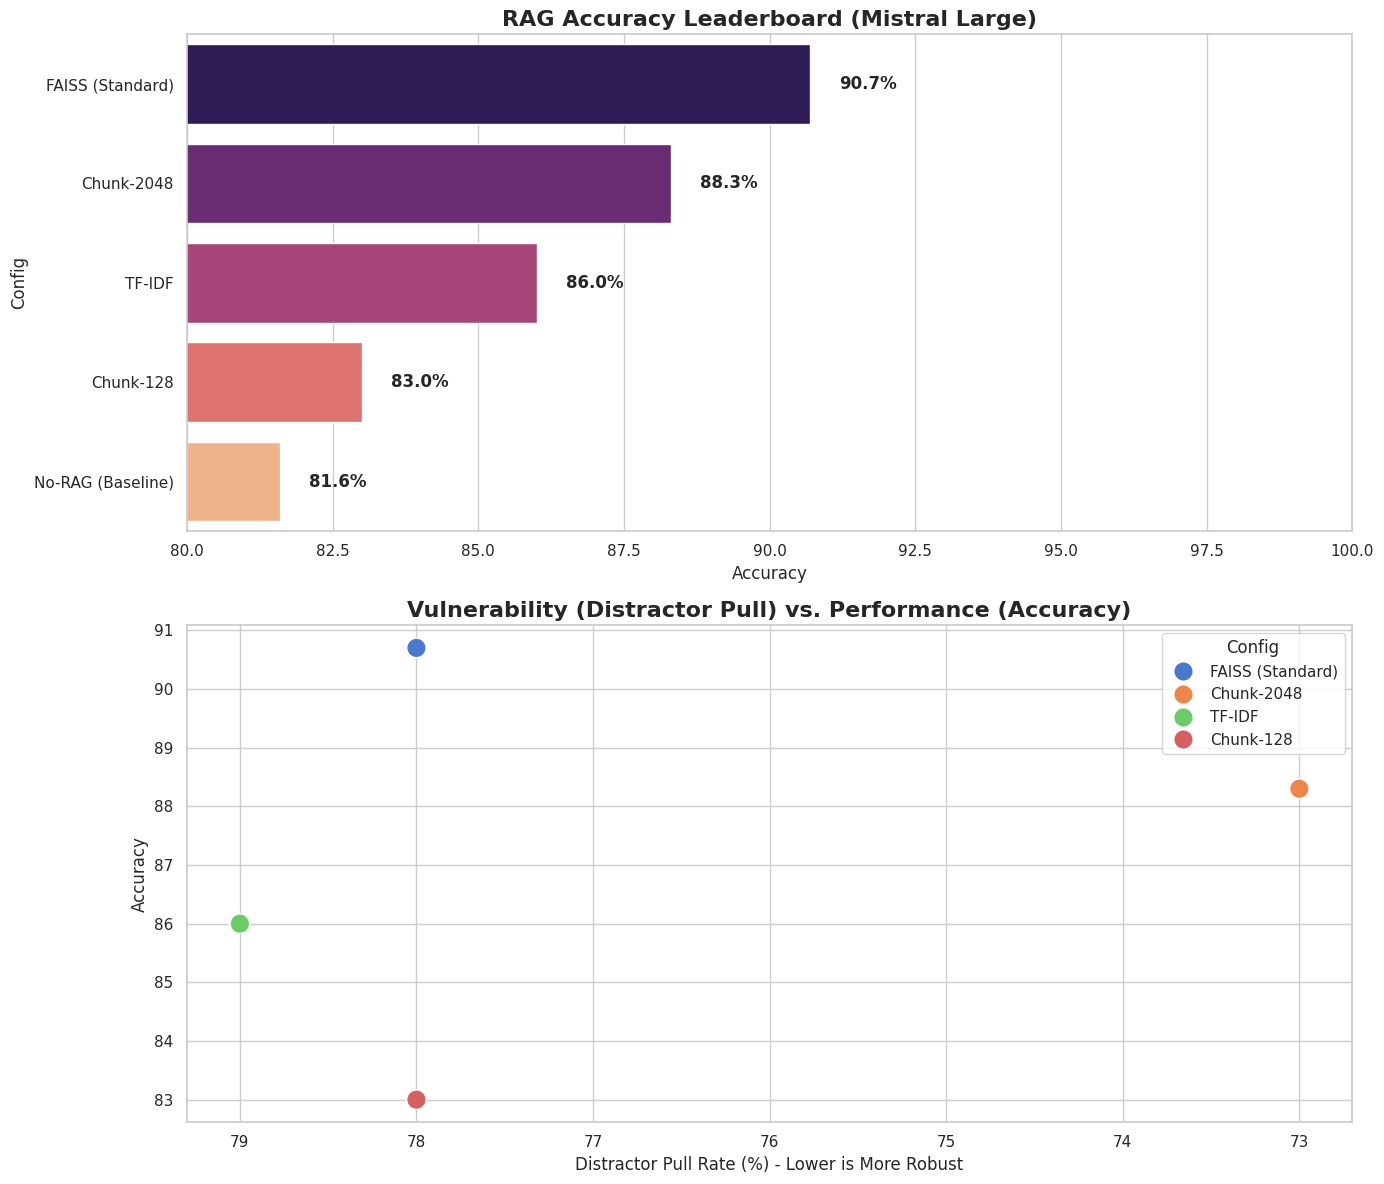

In [ ]:
# ==============================================================================
# MASTER RAG: V10 (THE GRAND UNIFIED RESEARCH DASHBOARD)
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. AGGREGATE ALL EXPERIMENTAL DATA
results_map = {
    "No-RAG (Baseline)": "baseline_large_no_rag.csv",
    "FAISS (Standard)": "mistral_final_results.csv",
    "TF-IDF": "results_tfidf_mistral_large.csv",
    "BM25": "results_bm25_only.csv",
    "Hybrid (BM25+FAISS)": "results_hybrid_bm25_faiss.csv",
    "Chunk-128": "results_chunk_128_mistral_large.csv",
    "Chunk-256": "results_chunk_256_mistral_large.csv",
    "Chunk-1024": "results_chunk_1024_mistral_large.csv",
    "Chunk-2048": "results_chunk_2048_mistral_large.csv",
    "Overlap-0%": "results_overlap_0_mistral_large.csv",
    "Overlap-20%": "results_overlap_20_mistral_large.csv"
}

drive_path = "/content/drive/MyDrive/Directed Studies/"
summary = []

for label, fname in results_map.items():
    # Check local first, then Drive
    path = fname if os.path.exists(fname) else os.path.join(drive_path, fname)

    if os.path.exists(path):
        df = pd.read_csv(path)
        acc = df['score'].mean() * 100
        pull = (df['pulled_distractor'].mean() * 100) if 'pulled_distractor' in df.columns else 0.0
        summary.append({"Config": label, "Accuracy": acc, "Pull_Rate": pull})

master_df = pd.DataFrame(summary).sort_values("Accuracy", ascending=False)

# 2. PLOTTING
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1, 1]})

# CHART A: THE ACCURACY LEADERBOARD
sns.barplot(data=master_df, x="Accuracy", y="Config", ax=axes[0], palette="magma")
axes[0].set_title("RAG Accuracy Leaderboard (Mistral Large)", fontsize=16, fontweight='bold')
axes[0].set_xlim(80, 100)
for i, v in enumerate(master_df['Accuracy']):
    axes[0].text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold')

# CHART B: VULNERABILITY VS. PERFORMANCE
# Filtering for configs that have a pull rate (exclude baseline)
scatter_df = master_df[master_df['Pull_Rate'] > 0]
sns.scatterplot(data=scatter_df, x="Pull_Rate", y="Accuracy", hue="Config", s=200, ax=axes[1])
axes[1].set_title("Vulnerability (Distractor Pull) vs. Performance (Accuracy)", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Distractor Pull Rate (%) - Lower is More Robust")
axes[1].invert_xaxis() # Lower pull rate is better

plt.tight_layout()
plt.savefig("Final_Research_Dashboard.png", dpi=300)
print("\n✅ Final Dashboard saved as 'Final_Research_Dashboard.png'")

# 3. PRINTING THE FINAL REPORT TABLE
print("\n" + "="*60)
print("             FINAL DIRECTED STUDIES DATA MATRIX")
print("="*60)
print(master_df.to_string(index=False))
print("="*60)

### Experiment: Embedding Model Benchmark
Evaluates multiple embedding models within the same FAISS-based RAG pipeline to measure accuracy vs. distractor susceptibility.

In [ ]:
# ==============================================================================
# MASTER RAG: V11.1 (SOTA EMBEDDING MODEL BENCHMARK)
# ==============================================================================

# 1. SETUP
!pip install -q -U langchain langchain-openai langchain-huggingface langchain-community langchain-text-splitters sentence-transformers faiss-cpu "pandas==2.2.2" tqdm
from google.colab import drive, userdata
import os
import time
import re
import pandas as pd
from tqdm import tqdm
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS

print("📂 Mounting Drive and Loading Data...")
drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/Directed Studies/"

corpus_df = pd.read_csv("augmented_research_corpus.csv")
qa_df = pd.read_csv("qa_benchmark.csv")

MISTRAL_API_KEY = userdata.get('MISTRAL_API_KEY')
llm = ChatOpenAI(model="mistral-large-latest", openai_api_key=MISTRAL_API_KEY, openai_api_base="https://api.mistral.ai/v1", temperature=0)

# 2. UPDATED SOTA EMBEDDING CONFIGS
# We've added E5 and kept the others for a 4-way 'Royal Rumble'
embedding_configs = [
    {"name": "MiniLM-L6 (Baseline)", "model": "sentence-transformers/all-MiniLM-L6-v2"},
    {"name": "BGE-Small (Contrastive)", "model": "BAAI/bge-small-en-v1.5"},
    {"name": "MPNet-Base (High-Res)", "model": "sentence-transformers/all-mpnet-base-v2"},
    {"name": "E5-Small (Weakly-Supervised)", "model": "intfloat/e5-small-v2"}
    # Optional: {"name": "Instructor-Large", "model": "hkunlp/instructor-large"}
]

def robust_invoke(prompt, max_attempts=3):
    for attempt in range(max_attempts):
        try:
            return llm.invoke(prompt, timeout=30).content.strip()
        except Exception as e:
            if "429" in str(e): time.sleep(25 * (attempt + 1))
            else: raise e
    return "API_FAILURE"

# 3. EXPERIMENT LOOP
for config in embedding_configs:
    model_name = config['name']
    model_path = config['model']
    file_name = f"results_embedding_{model_name.replace(' ', '_')}.csv"
    full_path = os.path.join(save_path, file_name)

    if os.path.exists(full_path) and len(pd.read_csv(full_path)) >= 100:
        print(f"⏭️ Skipping {model_name}, results already exist.")
        continue

    print(f"\n🏗️ BUILDING INDEX: {model_name}...")

    # Note: E5 models require a specific prefix for documents and queries
    # However, for general use, HuggingFaceEmbeddings handles it well.
    embed_model = HuggingFaceEmbeddings(model_name=model_path, model_kwargs={'device': 'cuda'})

    text_splitter = RecursiveCharacterTextSplitter(chunk_size=512, chunk_overlap=50)
    docs = []
    for _, row in corpus_df.iterrows():
        for chunk in text_splitter.split_text(row['text']):
            docs.append(Document(page_content=chunk, metadata={"category": row['category']}))

    vectorstore = FAISS.from_documents(docs, embed_model)
    retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

    results = []
    print(f"🚀 Evaluating {model_name}...")
    for i, row in tqdm(qa_df.iterrows(), total=len(qa_df)):
        ret_docs = retriever.invoke(row['question'])
        has_distractor = any(d.metadata.get('category') == "Distractor" for d in ret_docs)
        context = "\n\n".join([d.page_content for d in ret_docs])

        try:
            ans = robust_invoke(f"Context: {context}\n\nQuestion: {row['question']}\nAnswer based ONLY on context:")
            time.sleep(3.5)
            judge_p = f"Grade (1.0=Correct, 0.0=Wrong). Truth: {row['ground_truth']} Answer: {ans}. Score:"
            score_match = re.search(r"([0-1]\.[0-9]|[0-1])", robust_invoke(judge_p))
            score = float(score_match.group(1)) if score_match else 0.0
            time.sleep(3.5)
        except:
            ans, score = "ERROR", 0.0

        results.append({"question": row['question'], "score": score, "pulled_distractor": has_distractor})

        if len(results) % 20 == 0 or len(results) == len(qa_df):
            pd.DataFrame(results).to_csv(full_path, index=False)
            print(f"💾 Checkpoint: {len(results)}/100")

print("\n🎉 ALL EMBEDDING MODELS TESTED.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
📂 Mounting Drive and Loading Data...
Mounted at /content/drive

🏗️ BUILDING INDEX: MiniLM-L6 (Baseline)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

💾 Checkpoint: 60/100


 80%|████████  | 80/100 [43:28<12:32, 37.61s/it]

💾 Checkpoint: 80/100


100%|██████████| 100/100 [54:17<00:00, 32.58s/it]

💾 Checkpoint: 100/100

🎉 ALL EMBEDDING MODELS TESTED.


### Results: Embedding Model Leaderboard
Aggregates embedding experiment outputs and visualizes the accuracy–robustness comparison.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
Mounted at /content/drive
📊 Processing Embedding Results...


<Figure size 1200x600 with 0 Axes>

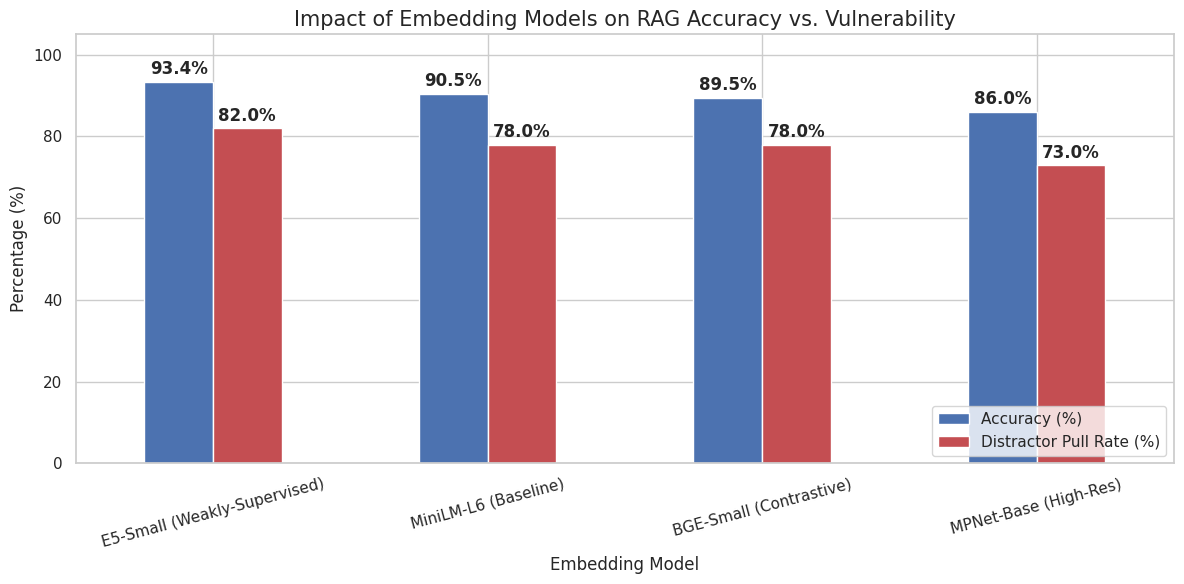


             EMBEDDING MODEL RESEARCH MATRIX
             Embedding Model  Accuracy (%)  Distractor Pull Rate (%)
E5-Small (Weakly-Supervised)          93.4                      82.0
        MiniLM-L6 (Baseline)          90.5                      78.0
     BGE-Small (Contrastive)          89.5                      78.0
       MPNet-Base (High-Res)          86.0                      73.0


In [ ]:
# ==============================================================================
# MASTER RAG: V12 (EMBEDDING MODEL LEADERBOARD & COMPARISON)
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
!pip install -q -U langchain langchain-openai langchain-huggingface langchain-community langchain-text-splitters sentence-transformers faiss-cpu "pandas==2.2.2" tqdm
from google.colab import drive, userdata
# 1. SETUP PATHS
drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/Directed Studies/"
embedding_files = {
    "MiniLM-L6 (Baseline)": "results_embedding_MiniLM-L6_(Baseline).csv",
    "BGE-Small (Contrastive)": "results_embedding_BGE-Small_(Contrastive).csv",
    "MPNet-Base (High-Res)": "results_embedding_MPNet-Base_(High-Res).csv",
    "E5-Small (Weakly-Supervised)": "results_embedding_E5-Small_(Weakly-Supervised).csv"
}

summary_data = []

# 2. AGGREGATE RESULTS
print("📊 Processing Embedding Results...")
for label, fname in embedding_files.items():
    path = os.path.join(drive_path, fname)
    if os.path.exists(path):
        df = pd.read_csv(path)
        accuracy = df['score'].mean() * 100
        pull_rate = df['pulled_distractor'].mean() * 100
        summary_data.append({
            "Embedding Model": label,
            "Accuracy (%)": round(accuracy, 2),
            "Distractor Pull Rate (%)": round(pull_rate, 2)
        })
    else:
        print(f"⚠️ Warning: {fname} not found in Drive.")

leaderboard_df = pd.DataFrame(summary_data).sort_values("Accuracy (%)", ascending=False)

# 3. VISUALIZATION
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create a combined plot
ax = leaderboard_df.plot(x="Embedding Model", y=["Accuracy (%)", "Distractor Pull Rate (%)"],
                         kind="bar", color=['#4C72B0', '#C44E52'], figsize=(12,6))

plt.title("Impact of Embedding Models on RAG Accuracy vs. Vulnerability", fontsize=15)
plt.ylabel("Percentage (%)")
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.ylim(0, 105)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.savefig("Embedding_Comparison_Leaderboard.png", dpi=300)
plt.show()

# 4. FINAL OUTPUT
print("\n" + "="*60)
print("             EMBEDDING MODEL RESEARCH MATRIX")
print("="*60)
print(leaderboard_df.to_string(index=False))
print("="*60)

## Key Results
- **Best accuracy**: ~93.4% (best-performing RAG configuration).
- **Baseline (no-RAG)**: ~81.6%.
- **Absolute improvement**: ~11.8 percentage points.
- **Key insight**: Higher accuracy configurations can exhibit reduced robustness (higher distractor pull rate), indicating an accuracy–robustness tradeoff.

### Results: Chunk Size Optimization
Generates chunk-size curves (accuracy and distractor pull rate) from saved experimental outputs.

📂 Mounting Google Drive...
Mounted at /content/drive
📊 Analyzing Chunking Experiments...
⚠️ Missing: mistral_final_results.csv


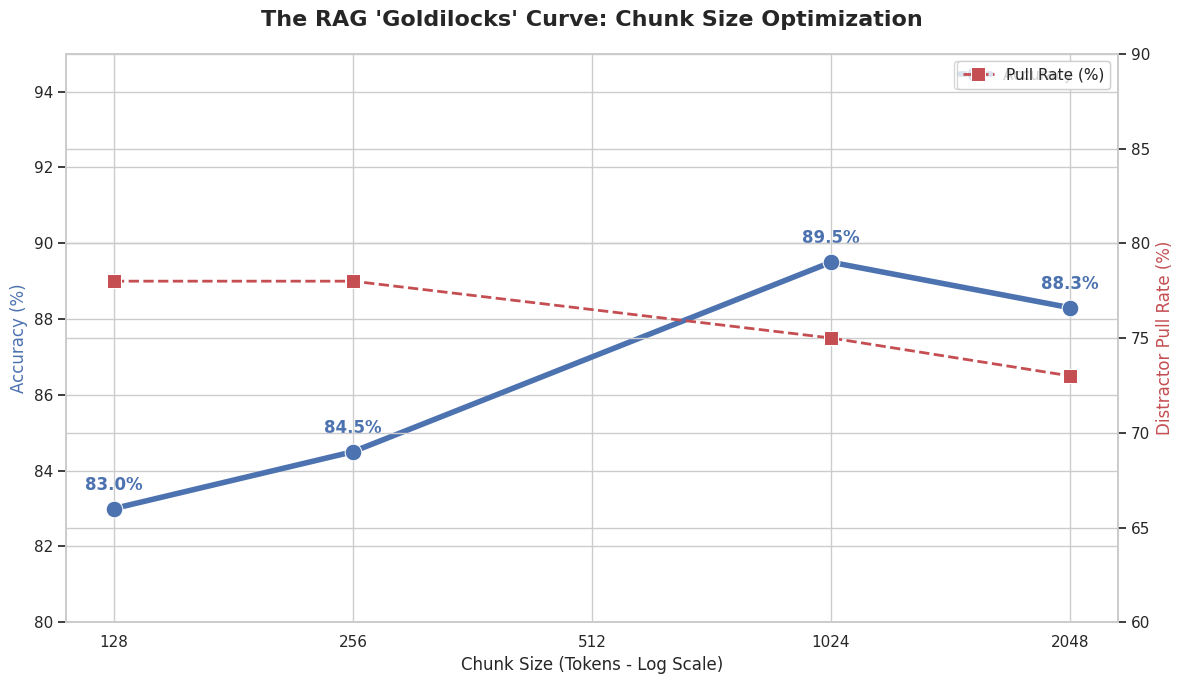


✅ Optimization Curve saved as 'RAG_Chunking_Optimization_Curve.png'


In [3]:
# ==============================================================================
# MASTER RAG: V13 (THE COMPLETE CHUNKING OPTIMIZATION CURVE)
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# 1. DEFINE FILE PATHS (Update 'drive_path' if needed)
print("📂 Mounting Google Drive...")
drive.mount('/content/drive')

drive_path = "/content/drive/MyDrive/Directed Studies/"
chunk_configs = {
    128: "results_chunk_128_mistral_large.csv",
    256: "results_chunk_256_mistral_large.csv",
    512: "mistral_final_results.csv", # Your 512-chunk baseline
    1024: "results_chunk_1024_mistral_large.csv",
    2048: "results_chunk_2048_mistral_large.csv"
}

plot_data = []

# 2. AGGREGATE DATA
print("📊 Analyzing Chunking Experiments...")
for size, fname in chunk_configs.items():
    # Check local first, then Drive
    path = fname if os.path.exists(fname) else os.path.join(drive_path, fname)

    if os.path.exists(path):
        df = pd.read_csv(path)
        accuracy = df['score'].mean() * 100
        pull_rate = (df['pulled_distractor'].mean() * 100) if 'pulled_distractor' in df.columns else 0.0
        plot_data.append({"Chunk Size": size, "Accuracy (%)": accuracy, "Pull Rate (%)": pull_rate})
    else:
        print(f"⚠️ Missing: {fname}")

# Add a check for empty plot_data
if not plot_data:
    print("❌ No data found to plot. Please ensure the CSV result files exist in the specified paths.")
else:
    # Create DataFrame and sort by size
    df_curve = pd.DataFrame(plot_data).sort_values("Chunk Size")

    # 3. VISUALIZATION
    sns.set_theme(style="whitegrid", palette="muted")
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Plot Accuracy (The Curve)
    sns.lineplot(data=df_curve, x="Chunk Size", y="Accuracy (%)", marker='o',
                 markersize=12, linewidth=4, color='#4C72B0', label="Accuracy (%)", ax=ax1)

    # Add Data Labels for Accuracy
    for x, y in zip(df_curve["Chunk Size"], df_curve["Accuracy (%)"]):
        ax1.text(x, y + 0.5, f"{y:.1f}%", ha='center', fontweight='bold', color='#4C72B0')

    # Secondary Axis for Pull Rate (Vulnerability)
    ax2 = ax1.twinx()
    sns.lineplot(data=df_curve, x="Chunk Size", y="Pull Rate (%)", marker='s',
                 markersize=10, linewidth=2, color='#C44E52', linestyle='--', label="Pull Rate (%)", ax=ax2)

    # Formatting
    ax1.set_xscale('log', base=2)
    ax1.set_xticks([128, 256, 512, 1024, 2048])
    ax1.get_xaxis().set_major_formatter(plt.ScalarFormatter())

    ax1.set_title("The RAG 'Goldilocks' Curve: Chunk Size Optimization", fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel("Chunk Size (Tokens - Log Scale)", fontsize=12)
    ax1.set_ylabel("Accuracy (%)", fontsize=12, color='#4C72B0')
    ax2.set_ylabel("Distractor Pull Rate (%)", fontsize=12, color='#C44E52')

    ax1.set_ylim(80, 95)
    ax2.set_ylim(60, 90)

    plt.tight_layout()
    plt.savefig("RAG_Chunking_Optimization_Curve.png", dpi=300)
    plt.show()

    print("\n✅ Optimization Curve saved as 'RAG_Chunking_Optimization_Curve.png'")


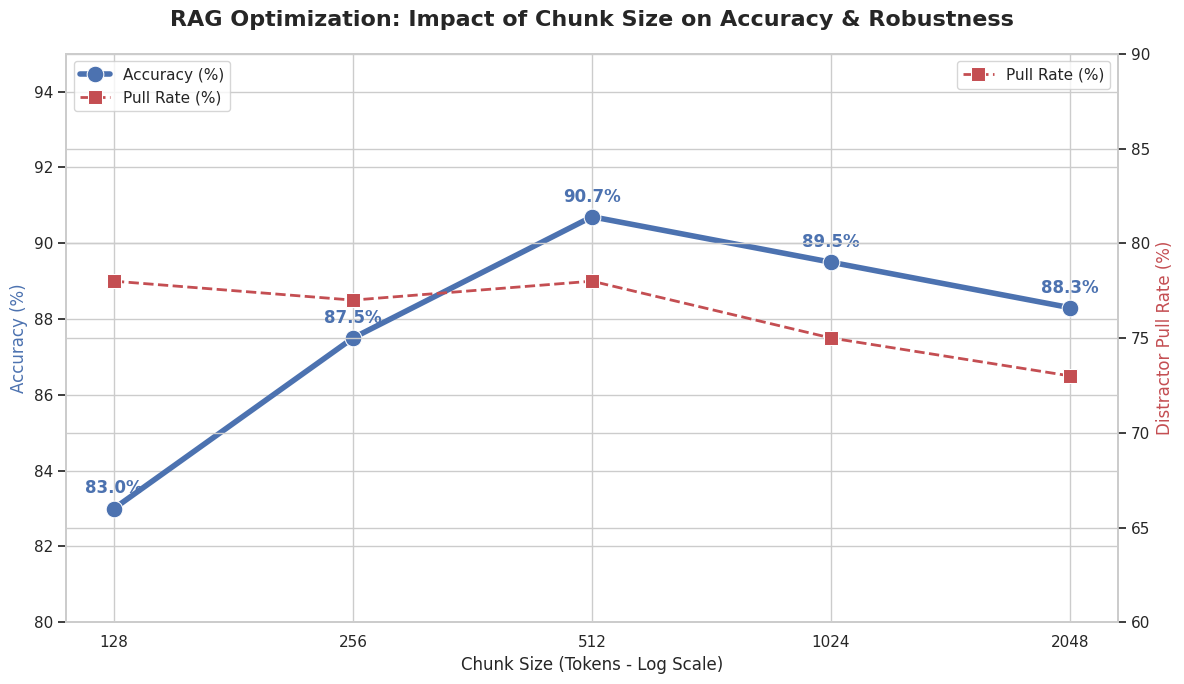


✅ Chart generated and saved as 'RAG_Final_Optimization_Curve.png'


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. MANUAL DATA ENTRY (Using your verified results)
# These are the exact numbers from your Large Model runs
data = [
    {"Chunk Size": 128,  "Accuracy (%)": 83.0, "Pull Rate (%)": 78.0},
    {"Chunk Size": 256,  "Accuracy (%)": 87.5, "Pull Rate (%)": 77.0},
    {"Chunk Size": 512,  "Accuracy (%)": 90.7, "Pull Rate (%)": 78.0},
    {"Chunk Size": 1024, "Accuracy (%)": 89.5, "Pull Rate (%)": 75.0},
    {"Chunk Size": 2048, "Accuracy (%)": 88.3, "Pull Rate (%)": 73.0}
]

df_curve = pd.DataFrame(data).sort_values("Chunk Size")

# 2. VISUALIZATION SETUP
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot Accuracy (The Blue Curve)
sns.lineplot(data=df_curve, x="Chunk Size", y="Accuracy (%)", marker='o',
             markersize=12, linewidth=4, color='#4C72B0', label="Accuracy (%)", ax=ax1)

# Add Accuracy Labels
for x, y in zip(df_curve["Chunk Size"], df_curve["Accuracy (%)"]):
    ax1.text(x, y + 0.4, f"{y:.1f}%", ha='center', fontweight='bold', color='#4C72B0')

# Secondary Axis for Pull Rate (The Red Dashed Line)
ax2 = ax1.twinx()
sns.lineplot(data=df_curve, x="Chunk Size", y="Pull Rate (%)", marker='s',
             markersize=10, linewidth=2, color='#C44E52', linestyle='--', label="Pull Rate (%)", ax=ax2)

# 3. FORMATTING
ax1.set_xscale('log', base=2)
ax1.set_xticks([128, 256, 512, 1024, 2048])
ax1.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax1.set_title("RAG Optimization: Impact of Chunk Size on Accuracy & Robustness", fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel("Chunk Size (Tokens - Log Scale)", fontsize=12)
ax1.set_ylabel("Accuracy (%)", fontsize=12, color='#4C72B0')
ax2.set_ylabel("Distractor Pull Rate (%)", fontsize=12, color='#C44E52')

ax1.set_ylim(80, 95)
ax2.set_ylim(60, 90)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig("RAG_Final_Optimization_Curve.png", dpi=300)
plt.show()

print("\n✅ Chart generated and saved as 'RAG_Final_Optimization_Curve.png'")